### 🗂️ PROYECTO INTEGRADOR MODULO 4 - AVANCE 2

**BREVE RESUMEN**
Tenemos nuestro socio FinanceGuard, quien es un banco digital que ha experimentado un crecimiento exponencial en los últimos años, alcanzando  10000 clientes activos. Sin embargo, la dirección ha detectado un incremento preocupante en la tasa de abandono de clientes (churn), que actualmente alcanza el 20% anual, resultando en pérdidas millonarias. 
Para revertir esta situación, la compañía busca aprovechar el potencial del análisis de datos y el aprendizaje automático. Para el desarrollo de un sistema predictivo que identifique a los clientes con mayor probabilidad de abandonar la entidad, facilitando estrategias de retención más efectivas.

### 🔎 CONTEXTO DE NUESTROS OBJETIVOS PARA ESTE AVANCE
Desarrollaremos un o varios modelos de Machine Learning que prediga qué clientes tienen mayor probabilidad de abandonar el banco **(CHURN)**. Este modelo tendrá como objetivo facilitar información importante de posibles clientes ***CHURN*** para los equipos de marketing y retención, con el fin de que éstos puedan implementar estrategias personalizadas para la retención de clientes en tiempo oportuno. 
En nuestro primer avance, logramos incorporar un modelo de regresión logistica con resultados en las metricas de evaluación bajos para lo solicitado. No obstante, en este segundo avance aplicaremos multiples algoritmos/modelos de aprendizaje y evaluaremos el rendimiento, realizaremos comparaciones entre los modelos y se realizará sugerencias, en nuestra sección **"Conclusiones"** sobre el modelo más optimo según la necesidad del negocio.

**🎯 Avance 2 - Entrenamiento de Múltiples Algoritmos, aplicación de Gradient Boosting, evaluación y comparación**
- Entrenamiento comparativo de múltiples algoritmos: entrenar nuestro modelo base (Regresión Logística), a su vez entrenar otros algoritmos (como Gradient Boosting: XGBoost, LightGBM y CatBoost) de Machine Learning y/o modelos (como: Random Forest, Tree Decisores, etc.) usando exactamente las mismas particiones de datos.

- Evaluación y selección del mejor modelo: medir, comparar y analizar el rendimiento de cada algoritmo mediante métricas clave (Accuracy, Precision, Recall, F1-Score y ROC-AUC) para determinar cuál ofrece la mejor capacidad predictiva para resolver el problema de churn.

- Realizar un analisis descriptivo final con una conclusión consistente del porque se sugiere la utilización del algoritmo/modelo ofrecido.

### ▶️ COMENZANDO AVANCE 2

### 🚀 IMPORTACIÓN DE LIBRERIAS


In [3]:
import pandas as pd                     # Para manejo y limpieza de los DataFrame (el Dataset)
import numpy as np                      # Para realización de formulas matematicas
import seaborn as sns                   # Para mayor defición de mis graficas realizadas con Matplotlib
import matplotlib.pyplot as plt         # Para creación de graficas estructuradas con diferentes estilos
import warnings                         # Para la cancelación de mensajes de errores en la generación de graficas
import optuna                           # Optuna para optimización bayesiana (opcional)
warnings.filterwarnings('ignore')       # Para ignorar mensajes de "warning" en la realización de laas graficas


from IPython.display import display     # Para mejor visualización del Dataset descargado en el DataFrame

import statsmodels.api as sm            # Para calcular los Intervalos de Confianza

from sklearn.ensemble import RandomForestClassifier # Para la creación de Random Forest
from sklearn.ensemble import StackingClassifier # Para Stacking (Asamble de  Modelo)
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

from sklearn.metrics import (
    ConfusionMatrixDisplay, confusion_matrix) #Para nuestra Matriz de Confusión

from sklearn.metrics import (
    average_precision_score,
    accuracy_score,                     
    auc,
    roc_auc_score,
    classification_report,              # Para la Generación de todas nuestras Metricas Evaluadoras del Modelo
    f1_score,                           # Metricas como "Recall, Precision, F1-Score y Accuracy"
    precision_score,
    recall_score,
    roc_curve,
    precision_recall_curve,
)

from sklearn.model_selection import (
    train_test_split,                                 # Para Split básico: train (80%), test (20%)
    StratifiedKFold,
    cross_val_score,
    GridSearchCV,
    KFold,
    TimeSeriesSplit,
    cross_validate,
)

from sklearn.preprocessing import StandardScaler      # Para escalar valores numericas
from sklearn.preprocessing import LabelEncoder        # Para convertir valores categoricos a numeros o a BOOL
from sklearn.linear_model import LogisticRegression   # Para la creación e implementación de nuestro modelo de Regresión Logistica

from optuna.visualization import plot_optimization_history, plot_param_importances

# Configuación base de mis graficos:
plt.style.use('seaborn-v0_8-whitegrid')   # Cuadrícula sutil de fondo
plt.rcParams.update({
    'figure.figsize': (10, 6),            # Tamaño estándar 
    'axes.titlesize': 14,                 # Tamaño de los titulos
    'axes.titleweight': 'bold',           # Titulos en negritas
    'axes.titlepad': 15                   # Ubicación del titulo para mayor visualización de la gráfica
})

# Selecciones del colores:
colors = ["#1B365D", "#4A90E2", "#95A5A6", "#9E1B32", "#E06666"]
sns.set_palette(sns.color_palette(colors))

# Configuración base de mi reproducibilidad para mis operaciones de numpy (algunos modelos lo necesitan)
np.random.seed(42)

print("Librerías descargadas con exito!🚀")

Librerías descargadas con exito!🚀


### 🔄️ CARGA DEL DATASET Y EDA

### ❗ INFORMACIÓN IMPORTANTE:
**Recordemos que exportamos nuestras Features y Target, tanto de entrenamiento como de validación en nuestro Avance 1 (Notebook anterior) a varios archivos .CSV bajo los nombres (x_train_scaled - x_test_scaled - y_train - y_test).**

✅ Se realiza carga de las variables predictoras ya escaladas (x_train_scaled - x_test_scaled) y mi variable a predecir (y_train - y_test) desde un formato .CSV. 

✅ Se realiza evaluación y visualización de mis datos (que esten correctos y no haya perdido información en la exportación)

**🔎 Obsersaciones de mis variables**

***- x_train_scaled:*** 
Cuenta con un total de: 8,000 filas, 11 columnas. Tal cual como se realizó el split previamente en nuestro modelo de Regresión Logística. Con tipos de datos "Float". 
Datos se visualizan escalados

***- x_test_scaled:***
Cuenta con un total de: 2,000 filas, 11 columnas. Tal cual como se realizó el split previamente en nuestro modelo de Regresión Logística. Con tipos de datos "Float". 
Datos se visualizan escalados

***- y_train:*** 
Cuenta con un total de 8,000 filas, una sola columna. Tal cual se realizó el Split previamente en nuestro modelo de Regresión Logística. Con tipos de datos "Int".
Recordemos que estos no fueron escalados (ya cuentan con datos de 0 y 1.

***- y_test:***
Cuenta con un total de 2,000 filas, una sola columna. Tal cual se realizó el Split previamente en nuestro modelo de Regresión Logística. Con tipos de datos "Int".
Recordemos que estos no fueron escalados (ya cuentan con datos de 0 y 1.

***- En y_train tenemos un total de:***
0:    6370
1:    1630

***- En y_test tenemos un total de:***
0:    1593
1:    407

### ✅ ¡¡Variables listas para ser trabajadas!!

In [4]:
# Cargando datos...

print(f"▶️ Realizando carga de mis variables predecibles y variable a predecir usadas en nuestro modelo de Regresión Logistica...")

# 1. Cargar datos preprocesados y escalados:
x_train_scaled = pd.read_csv("../data/x_train_scaled.csv")
x_test_scaled = pd.read_csv("../data/x_test_scaled.csv")
y_train = pd.read_csv("../data/y_train.csv").squeeze("columns")
y_test = pd.read_csv("../data/y_test.csv").squeeze("columns")

# 2. Confirmando estado de mis datos:
print("\n🔴 OBSERVACIONES IMPORTANTES")
print(f"\nDimensiones de mi Dataset de entrenamiento (x_train_scaled):\nfilas: {x_train_scaled.shape[0]:,}, columnas: {x_train_scaled.shape[1]:,}\n")
print("-"*100)
print(f"\nDimensiones de mi Dataset de test (x_test_scaled):\nfilas: {x_test_scaled.shape[0]:,}, columnas: {x_test_scaled.shape[1]:,}\n")
print("-"*100)
print(f"\nDimensiones de mi variable a prececir (set de entrenamiento (y_train)):\nfilas: {y_train.shape[0]:,}\n")
print("-"*100)
print(f"\nDimensiones de mi variable a prececir (set de test (y_test)):\nfilas: {y_test.shape[0]:,}\n")
print("-"*100)
print(f"\nTotal de valores únicos en nuestra variable a predecir (set de test - y_test): {y_test.value_counts()}\n")
print("-"*100)
print(f"\nTotal de valores únicos en nuestra variable a predecir (set de entrenamiento - y_train): {y_train.value_counts()}\n")
print(f"🚨 Variables predictoras de entrenamiento y test se encuentren escaladas y con un split correcto\n")
print("-"*100)
with pd.option_context('display.float_format', '{:,.2f}'.format):
    print(f"\nSet de entrenamiento:  resumen estadístico descriptivo")
    display(x_train_scaled.describe()) #Para Visualizar que mis variables si esten escaladas tal cual se exportó el Dataset
    print(f"Set de test:  resumen estadístico descriptivo")
    display(x_test_scaled.describe())  ##Para Visualizar que mis variables si esten escaladas tal cual se exportó el Dataset

print(f"🚨 Visualizando nuestro DataFrame y su contenido en nuestras variables predictoras")
print("-"*100)
print("Set de entrenamiento del modelo (x_train_scaled)")
print(f"{x_train_scaled.head()}\n")
print("-"*100)
print(f"set de prueba / validación del modelo (x_test_scaled)")
print(f"{x_test_scaled.head()}")
print("-"*100)
print(f"🚨 Tipos de datos de nuestras variables predictoras:")
print("Tipo de datos (set de entrenamiento)")
print(f"{x_train_scaled.info()}")
print("Tipo de datos (set de test)")
print(f"{x_test_scaled.info()}")

▶️ Realizando carga de mis variables predecibles y variable a predecir usadas en nuestro modelo de Regresión Logistica...

🔴 OBSERVACIONES IMPORTANTES

Dimensiones de mi Dataset de entrenamiento (x_train_scaled):
filas: 8,000, columnas: 11

----------------------------------------------------------------------------------------------------

Dimensiones de mi Dataset de test (x_test_scaled):
filas: 2,000, columnas: 11

----------------------------------------------------------------------------------------------------

Dimensiones de mi variable a prececir (set de entrenamiento (y_train)):
filas: 8,000

----------------------------------------------------------------------------------------------------

Dimensiones de mi variable a prececir (set de test (y_test)):
filas: 2,000

----------------------------------------------------------------------------------------------------

Total de valores únicos en nuestra variable a predecir (set de test - y_test): Exited
0    1593
1     407
Name

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain
count,"8,000.00","8,000.00","8,000.00","8,000.00","8,000.00","8,000.00","8,000.00","8,000.00","8,000.00","8,000.00","8,000.00"
mean,-0.00,0.00,0.00,-0.00,-0.00,-0.00,0.00,0.00,-0.00,0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-3.11,-1.10,-1.99,-1.73,-1.23,-0.91,-1.56,-1.03,-1.74,-0.58,-0.58
25%,-0.69,-1.10,-0.66,-0.70,-1.23,-0.91,-1.56,-1.03,-0.86,-0.58,-0.58
50%,0.01,0.91,-0.18,-0.01,0.33,-0.91,0.64,0.97,-0.00,-0.58,-0.58
75%,0.69,0.91,0.48,1.03,0.82,0.81,0.64,0.97,0.85,1.73,1.73
max,2.06,0.91,5.04,1.72,2.60,4.25,0.64,0.97,1.75,1.73,1.73


Set de test:  resumen estadístico descriptivo


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain
count,"2,000.00","2,000.00","2,000.00","2,000.00","2,000.00","2,000.00","2,000.00","2,000.00","2,000.00","2,000.00","2,000.00"
mean,-0.01,-0.03,-0.01,-0.01,0.01,0.01,-0.04,0.00,0.03,0.00,-0.03
std,1.00,1.00,0.98,0.99,1.01,1.00,1.02,1.00,1.02,1.00,0.98
min,-3.11,-1.10,-1.99,-1.73,-1.23,-0.91,-1.56,-1.03,-1.74,-0.58,-0.58
25%,-0.71,-1.10,-0.66,-1.04,-1.23,-0.91,-1.56,-1.03,-0.83,-0.58,-0.58
50%,-0.01,0.91,-0.18,-0.01,0.34,-0.91,0.64,0.97,0.04,-0.58,-0.58
75%,0.70,0.91,0.48,0.68,0.83,0.81,0.64,0.97,0.92,1.73,-0.58
max,2.06,0.91,4.38,1.72,2.80,4.25,0.64,0.97,1.75,1.73,1.73


🚨 Visualizando nuestro DataFrame y su contenido en nuestras variables predictoras
----------------------------------------------------------------------------------------------------
Set de entrenamiento del modelo (x_train_scaled)
   CreditScore    Gender       Age    Tenure   Balance  NumOfProducts  \
0     1.058568  0.907507  1.715086  0.684723 -1.226059      -0.910256   
1     0.913626  0.907507 -0.659935 -0.696202  0.413288      -0.910256   
2     1.079274 -1.101919 -0.184931 -1.731895  0.601687       0.808830   
3    -0.929207  0.907507 -0.184931 -0.005739 -1.226059       0.808830   
4     0.427035  0.907507  0.955079  0.339492  0.548318       0.808830   

   HasCrCard  IsActiveMember  EstimatedSalary  Geography_Germany  \
0   0.641042       -1.030206         1.042084          -0.578313   
1   0.641042       -1.030206        -0.623556           1.729169   
2   0.641042        0.970680         0.308128           1.729169   
3   0.641042       -1.030206        -0.290199          -0

### 💻 1. REGRESIÓN LOGISTICA (PARTE 1)

**Breve Resumen**
En esta primera parte realizamos el entrenamiento de nuestro modelo de Regresión Logistica. realizando unaa configuración base para sus algoritmos. Donde tenemos:

- ✅ Selección de reproducibilidad: random_state = 42. Esto con el fin de tener los mismos resultados independientemente se corra el codigo.

- ✅ Convergencia: se selecciona un total de maximas iteraciones con max_iter, de 1000 conversiones, esto significa que será el límite de intentos que tendrá el modelo para conseguir la mejor solución matemática posible. Tengamos en cuenta que el valor predeterminado es de 100 iteraciones.
Importante: si obtenemos el mensaje: "ConvergenceWarning" se deberá revisar el modelo, ya que posiblemente el modelo no logró finalizar u/o encontrar predicciones relativamente cercanas.

- ✅ Solver: finalmente como motor de orientación y enfoque usamos el motor por defecto de sk-learn conocido como "lbfgs". (Nombre técnico es Limited-memory Broyden–Fletcher–Goldfarb–Shanno), ideal para datos con un rango de tamaño pequeño y mediano.

**Entrenamiento de mi Regresión Logistica**

- ✅ Se lleva acabo el entrenamiento del modelo con sk-learn, utilizando la función de clase: .fit. Se toma en cuenta unicamente los datos reservados para el entrenamiento (x_train_scaled y y_train). A su vez se realiza el calculo del sesgo del modelo y se visualiza en formato de porcentaje.

- ✅ Se realiza la impresión de los datos del modelo, como numero de iteraciones, solver, coeficientes e intercepto (sesgo).

**Calculo de las metricas generales**

- ✅ Se realiza los calculos de las metricas bases del modelo, en este caso Features (variables predictoras), coeficientes, odds-ratio, y el impacto porcentual de los odds-ratio. Esto para comprender que features son las de mayor peso para las predicciones de este modelo.

**❗Hallazgos importantes: intercepto / sesgo inicial del modelo:**
Concepto: representa el punto de partida del modelo antes de evaluar las características (features). Un sesgo negativo significa que el valor en log-odds está por debajo de cero. En términos simples: La tendencia base/natural del modelo es inclinarse hacia "No Churn".
**No obstante** la interpretación del porcentaje hace referencia a la probabilidad que tendria un cliente en ser "churn" si todas sus variables fueran cero (0) o nulas (sin features). Éste valor, el modelo lo asigna por defecto a éstos clientes.
***`Resumen:`*** -1.6459$ (Log-odds): Muestra una resistencia inicial al Churn (fuerza negativa hacia la fuga).
Probabilidad base (16.17%): Es el riesgo inherente promedio del dataset. A partir de este valor, las variables de cada cliente irán sumando riesgo (si tienen coeficiente positivo) o restando riesgo (si tienen coeficiente negativo).

**Visualización de Métricas de Validación**

- ✅ Se solicita a través de la libreria de sk-learn las predicciones del modelo con las clases: .predic y predict_proba (para obtener las probabilidades exactas de que un dato pertenezca a cada una de las clases posibles [0.15%, 0, 0.85%, dependiendo del caso], en lugar de dar solo la respuesta final resumida [0, o, 1]).

- ✅ Calculos de las métricas de validación para visualización mas profunda del comportamiento de nuestro modelo. Métricas como:
Accuracy: se le conoce como precisión, pero en este caso se refiere a la exactitud del modelo.
Precisión: Porcentaje predecidos que si fueron Churn.
Recall: Porcentaje real de churn detectados.
F1-Score: Balance entre precision y recall.

**Para éste modelo:** 
❌ Recall muy bajo del estandar. No se esta detectando a tiempo los verdaderos Churn.
🟩 Precisión Moderada. Hay un balance entre los falsos positivos (CHURN) y los verdaderos positivos.
🔎 Impacto porcentual:
Coeficientes Positivos (los más relevantes): 
- Edad (Age): a mayor edad, mas riesgo de ser churn (109%).
- País de residencia, especialmente Alemania (Geography_Germany): Si reside en Alemania, probabilidad de que sea churn (42%).
- Balance: mientras mayor sea el balance en cuenta, más probabilidad tiene el cliente de ser churn (17%).

Coeficientes Negativos:
- Miembro (IsActiveMember): si el cliente es miembro, reduce laa probabilidad de que sea churn (40%).
- Genero (Gender): en nuestro Dataset recordemos que el genero Femenino tenia más churn, a diferencia del genero Masculino, para éste modelo la feature Gender tiene un porcentaje negativo de 22.9%, lo que reduce la probabilidad de churn, alusivo al genero Masculino.
- CreditScore (8%) y NumOfProducts(6%): mientras más bajo sea el record crediticio y mientras menor sea la cantidad de producto por parte del cliente, menor es la probabilidad de churn. 
**`No Obstante`**, recordemos que en el Dataset tenemos un **`27%`** de clientes churn con **`solo un (1) producto`**, si bien el porcentaje es notoriamente menor a clientes con tres (3) y cuatro (4) productos.

Se sugiere **`revisar`** a detalles los benecifios para el tercer y cuarto producto una vez el cliente lo adquiere (si estos benedifcios son competitivos con el mercado) y, a su vez, **`revisar`** las condiciones para aquellos clientes que cuentan con solo un producto. 

In [5]:
# Variables ya escaladas, divididas y seleccionadas desde el Notebook anterior:
# x_train_scaled (set de entrenamiento features escalado)
# x_test_scaled (set de test features escalado)
# y_train (se de entrenamiento target)
# y_test (set de test target)

# 1. Algoritmo de mi modelo
modelo_rl = LogisticRegression(
    random_state= 42, # Reproducibilidad
    max_iter= 1000,   # Se aumenta conversiones para optimización de convergencia
    solver= 'lbfgs'   # Para mejorar el algoritmo de optimización
)

# 2. Entrenando modelo Regresión Logistica
print("\nEntrenando modelo Regresión Logistica!")
modelo_rl.fit(x_train_scaled, y_train)
prob_base = 1 / (1 + np.exp(-modelo_rl.intercept_[0])) # Queriendo ver el sesgo/intercepto como un porcentaje

print("\nModelo Entrenado Exitosamente 👍\n")
print("-"*100)
print("\nALGORITMOS DE MI MODELO:")
print(f"Solver: {modelo_rl.solver}")
print(f"Maximas Iteraciones: {modelo_rl.n_iter_[0]}")
print(f"Total de features: {len(modelo_rl.coef_[0])}\n")
print("-"*100)
print("\nSesgo: valor exacto que tendría la variable de predicción si todas mis features fueran exactamente iguales a cero")
print("O, si un cliente no tuviera Features")
print(f"Sesgo/Intercepto: {modelo_rl.intercept_[0]:.4f}\n")
print("-"*100)
print(f"\nProbabilidad base de Churn (con features promerio = 0, o ,clientes sin features): {prob_base * 100:.2f}%\n")
print("-"*100)

# 3. Generando los calculos de los coeficientes
coeficientes = pd.DataFrame({
    'Feature': x_train_scaled.columns,
    'Coeficiente': modelo_rl.coef_[0],
    'Abs_Coef': np.abs(modelo_rl.coef_[0])
})

# 4. Calculo Ratio e Impacto Porcentual, y ordeno por margnitud de mayor peso:
coeficientes['Odds_Ratio'] = np.exp(coeficientes['Coeficiente'])
coeficientes['Impacto_Porcentual'] = (coeficientes['Odds_Ratio'] - 1) * 100
coeficientes = coeficientes.sort_values('Abs_Coef', ascending = False)

# 5. Mostramos nuestros Coeficientes y Odds Ratio
print("\nCOEFICIENTES DE MI MODELO")
display(coeficientes)

# 6. Realizamos la visualización de las metricas de validación (Recall, Accuracy, F1-Score)
# Primero realizamos las predicciones de mi variable a predecir:
y_pred = modelo_rl.predict(x_test_scaled)
y_pred_proba = modelo_rl.predict_proba(x_test_scaled)[:, 1]

# 7. Realizamos calculos de las metricas en el print (Solo Churn):
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label=1)
recall = recall_score(y_test, y_pred, pos_label=1)
f1 = f1_score(y_test, y_pred, pos_label=1)

print("-"*100)
print(f"MÉTRICAS DE EVALUACIÓN Y CLASIFICACIÓN - CLASE CHURN (pos_label=1):")
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn'], digits=4))
print(f"Accuracy: {accuracy:.4f}  Accuraccy %: ({accuracy*100:.2f}%)")
print("-"*100)
print("Predicción para Clase Churn:")
print(f"Precisión: {precision:.4f}")
print(f"Porcentaje predecidos que si fueron Churn: {precision*100:.1f}")
print("-"*100)
print(f"Recall: {recall:.4f}")
print(f"Porcentaje real de churn detectados: {recall*100:.1f}")
print("-"*100)
print("Balance entre precision y recall (F1-Score):")
print(f"F1-Score: {f1:.4f}")
print("\nINTERPRETACIÓN RECALL Y PRECISION DEL MODELO")

# Interpretación de las Metricas de Validación:
# Validación Recall:
if recall < 0.5:
    print("❌ Recall muy bajo del estandar. No se esta detectando a tiempo los verdaderos Churn")
elif 0.5 <= recall <= 0.7:
    print("🟩 Recall Moderado. Se detecta a tiempo un buen pocentaje de los verdaderos Churn")
else:
    print("¡Recall Alto! Se detenta la mayoria de los verdaderos churn")

# Validación Precisión:
if precision < 0.5:
    print("🚨 Precisión baja. Se estan detectando muchos clientes NO CHURN, como CHURN")
elif 0.5 <= precision <= 0.7:
    print("🟩 Precisión Moderada. Hay un balance entre los falsos positivos (CHURN) y los verdaderos positivos")
else: 
    print("Precisión Alta. Concuerdan clientes verdaderos positivos con las prediciones del modelo")


Entrenando modelo Regresión Logistica!

Modelo Entrenado Exitosamente 👍

----------------------------------------------------------------------------------------------------

ALGORITMOS DE MI MODELO:
Solver: lbfgs
Maximas Iteraciones: 6
Total de features: 11

----------------------------------------------------------------------------------------------------

Sesgo: valor exacto que tendría la variable de predicción si todas mis features fueran exactamente iguales a cero
O, si un cliente no tuviera Features
Sesgo/Intercepto: -1.6459

----------------------------------------------------------------------------------------------------

Probabilidad base de Churn (con features promerio = 0, o ,clientes sin features): 16.17%

----------------------------------------------------------------------------------------------------

COEFICIENTES DE MI MODELO


,Feature,Coeficiente,Abs_Coef,Odds_Ratio,Impacto_Porcentual
2,Age,0.738847,0.738847,2.093520,109.351968
7,IsActiveMember,-0.515485,0.515485,0.597211,-40.278916
9,Geography_Germany,0.356679,0.356679,1.428578,42.857759
1,Gender,-0.260851,0.260851,0.770396,-22.960431
4,Balance,0.160622,0.160622,1.174241,17.424121
0,CreditScore,-0.085986,0.085986,0.917607,-8.239334
5,NumOfProducts,-0.070292,0.070292,0.932122,-6.787808
8,EstimatedSalary,0.047725,0.047725,1.048882,4.888247
6,HasCrCard,-0.032208,0.032208,0.968306,-3.169444
3,Tenure,-0.020071,0.020071,0.980129,-1.987113


----------------------------------------------------------------------------------------------------
MÉTRICAS DE EVALUACIÓN Y CLASIFICACIÓN - CLASE CHURN (pos_label=1):
              precision    recall  f1-score   support

    No Churn     0.8231    0.9667    0.8891      1593
       Churn     0.5891    0.1867    0.2836       407

    accuracy                         0.8080      2000
   macro avg     0.7061    0.5767    0.5864      2000
weighted avg     0.7755    0.8080    0.7659      2000

Accuracy: 0.8080  Accuraccy %: (80.80%)
----------------------------------------------------------------------------------------------------
Predicción para Clase Churn:
Precisión: 0.5891
Porcentaje predecidos que si fueron Churn: 58.9
----------------------------------------------------------------------------------------------------
Recall: 0.1867
Porcentaje real de churn detectados: 18.7
----------------------------------------------------------------------------------------------------
Balance e

### 1.1 REGRESIÓN LOGISTICA (PARTE 2)

**Matriz de Confusión - Curva ROC - AUC**

- ✅ Matriz de confusión: se realiza la creación de una lista vacia, para guardar en ella los valores que serán aplanados y corresponderan a la matriz de confisión.

- ✅ Función .flatten(): con el fin de aplanar los datos de y_test y y_pred y poder, extraer de éstos sus porcentajes con la libreria numpy.

- ✅ Función "for": se realiza para poder iterar en cada uno de los valores previamente aplanados con la función de clase .flatten(), a su vez, se guarda el formato en el que cada cuadro de la grafica va a mostrar las variables numericas, y se guarda toda esta información en nuestra lista vacia.

- ✅ El paso más importante, se utiliza la función de clase .reshape, para que los datos guardados en nuestra lista vacia esten bajo un formato de 2 listas array (como estaba originalmente). Ya que la grafica de Matriz de Confusión necesita un formato de 2 x 2.

- ✅ Finalmente se genera las especificaciones de la grafica y se genera las condiciones de lectura de los datos para las etiquetas tn, fp, fn, tp con la función: mc.ravel().

**Curva ROC - AUC**

- ✅ Con nuestras metricas de validación previamente generadas (accuracy, precisión, recall, f1-score), realizamos la grafica de nuestra Curva ROC - AUC, utilizando las funciones de la librería sk-learn, = roc_curve y = uac. Teniendo en cuenta que los datos utilizados para esta ocasión fueron nuestra variable a predecir (y_test) datos de validación, y nuestras predicciones exactas del modelo (y_pred_proba).

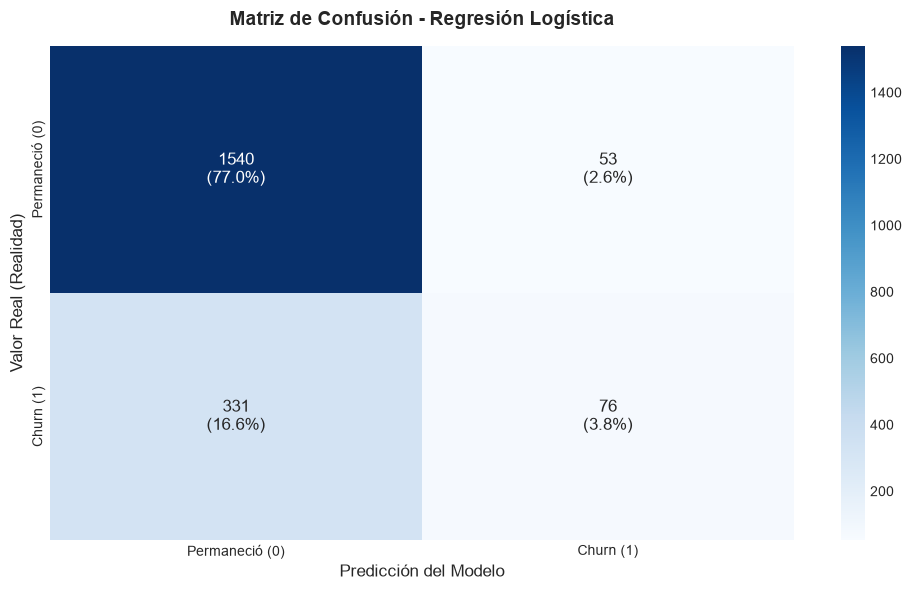

🚨 DESGLOSE DE LA MATRIZ DE CONFUSIÓN:
----------------------------------------------------------------------------------------------------
❗❗Falsos Negativos    (FN):  331 (Fugas no detectadas - ERROR GRAVE)
⭕ Falsos Positivos      (FP):   53 (Falsas alarmas de churn)
✅ Verdaderos Negativos  (TN): 1540 (Clientes retenidos predichos correctamente)
✅ Verdaderos Positivos  (TP):   76 (Clientes en churn detectados a tiempo)
----------------------------------------------------------------------------------------------------
🔎 METRICAS DE EVALUACIÓN PARA COMPLEMENTAR CURVA ROC - AUC
- Accuracy (Exactitud del modelo): 0.8080 (80.80%)
- Precision (Precisión de la predicción): 0.5891 (58.91%)
- Recall (Sensibilidad, cuantos clientes son captados en realidad): 0.1867 (18.67%)
- F1-Score (Balance entre la precisión del modelo y el recall): 0.2836 (28.36%)
- Área bajo la curva (ROC - AUC)
 (ROC - AUC: Distinción del modelo entre las 2 clases en todos los umbrales de decisión posibles): 0.7748 (77.

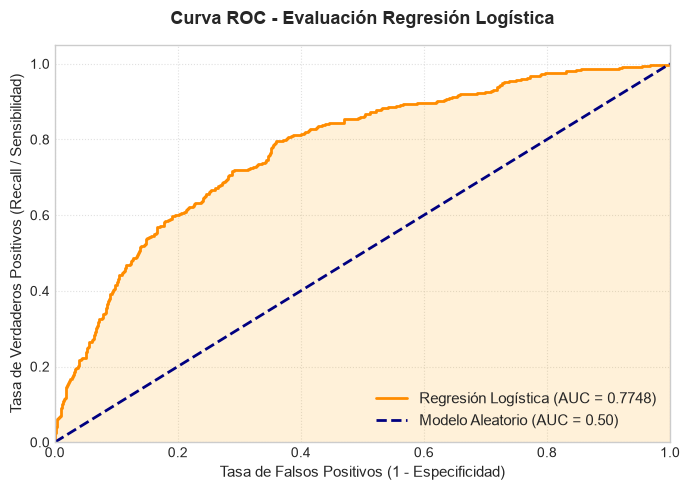

In [6]:
# 8. Curva ROC, AUC, Matriz de Confusión:
# 8.1 Matriz de Confusión, generada paso a paso:
# Genero la metrica con confusion_matrix y usamos nuestro y de test (valor validación) and y de prediccion (valores predecidos por mi modelo)
mc = confusion_matrix(y_test, y_pred)

# Agrego etiquetas de conteo y porcentaje:
etiquetas_lista = []

# Valores de los datos planos y sus porcentajes:
valores = mc.flatten()
porcentaje = (valores / mc.sum()) * 100

# Recorrido de ambos valores al mismo tiempo a través de un for y seting de laa matriz de confusión:
for i in range(len(valores)):
    val = valores[i]
    pctj = porcentaje[i]
    texto_cuadro = f"{val}\n({pctj:.1f}%)" # Como se veran los valores dentro de los cuadros de la matriz de confusión
    etiquetas_lista.append(texto_cuadro) # Guardamos los valores de texto_cuadro en nuestra lista previamente creadas (etiquetas_lista)

# Convertimos la lista creada en una matriz 2 x 2 para el grafico usando numpy (np.array)
labels = np.array(etiquetas_lista).reshape(2, 2)

# Genero detalles de la grafica:
plt.Figure(figsize=(7, 5))
sns.heatmap(
    mc,
    annot=labels,
    fmt='',
    cmap='Blues',
    xticklabels=['Permaneció (0)', 'Churn (1)'],
    yticklabels=['Permaneció (0)', 'Churn (1)'],
    annot_kws={'size':12},
)

# Realizo ajustes y afino detalles de los titulos de las etiquetas:
plt.title('Matriz de Confusión - Regresión Logística', fontsize=14, pad=15)
plt.xlabel('Predicción del Modelo', fontsize=12)
plt.ylabel('Valor Real (Realidad)', fontsize=12)
plt.tight_layout()
plt.show()

# Relaciono los valores correspondientes de Verdaderos Negativos (TN), Falsos Positivos (FP), Falsos Negativos (FN) y Verdaderos Positivos (TP)
tn, fp, fn, tp = mc.ravel()
print("🚨 DESGLOSE DE LA MATRIZ DE CONFUSIÓN:")
print("-" * 100)
print(f"❗❗Falsos Negativos    (FN): {fn:4d} (Fugas no detectadas - ERROR GRAVE)")
print(f"⭕ Falsos Positivos      (FP): {fp:4d} (Falsas alarmas de churn)")
print(f"✅ Verdaderos Negativos  (TN): {tn:4d} (Clientes retenidos predichos correctamente)")
print(f"✅ Verdaderos Positivos  (TP): {tp:4d} (Clientes en churn detectados a tiempo)")

# 8.2 Curva ROC:
# Iniciamos creando las variables del Rate Falso Positivos y Rate Verdadero Positivo con sklearn y sus umbrales de desición
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba) # thresholds 0.1, 0.2, 0.5, 0.8 (Umbrales de decisión)
roc_auc = auc(fpr, tpr)

# Mostramos resultados de nuestraas metricas previas, esta vez, para complementar la Curva Roc y Auc
print("-" * 100)
print("🔎 METRICAS DE EVALUACIÓN PARA COMPLEMENTAR CURVA ROC - AUC")
print(f"- Accuracy (Exactitud del modelo): {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"- Precision (Precisión de la predicción): {precision:.4f} ({precision*100:.2f}%)")
print(f"- Recall (Sensibilidad, cuantos clientes son captados en realidad): {recall:.4f} ({recall*100:.2f}%)")
print(f"- F1-Score (Balance entre la precisión del modelo y el recall): {f1:.4f} ({f1*100:.2f}%)")
print(f"- Área bajo la curva (ROC - AUC)")
print(f" (ROC - AUC: Distinción del modelo entre las 2 clases en todos los umbrales de decisión posibles): {roc_auc:.4f} ({roc_auc*100:.2f}%)")
print("-" * 100)

# Graficamos la Curva ROC- AUC
plt.figure(figsize=(7, 5))
plt.plot(
    fpr,
    tpr,
    color= 'darkorange',
    lw=2,
    label=f'Regresión Logística (AUC = {roc_auc:.4f})',
)
plt.fill_between(fpr, tpr, color='orange', alpha=0.15)
plt.plot(
    [0, 1],
    [0, 1],
    color='navy',
    lw=2,
    linestyle='--',
    label='Modelo Aleatorio (AUC = 0.50)'
)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)', fontsize=11)
plt.ylabel('Tasa de Verdaderos Positivos (Recall / Sensibilidad)', fontsize=11)
plt.title('Curva ROC - Evaluación Regresión Logística', fontsize=13, pad=15)
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

### 💻 2. RANDOM FOREST (PARTE 1 - BASE LINE MODELO ASAMBLE)

**Concepto Breve:**
Random Forest funciona creando un "bosque" de múltiples Árboles de Decisión independientes entrenados en paralelo. En lugar de confiar en lo que dice un solo árbol, hace que todos voten y toma la decisión de la mayoría.

1. Crea subconjuntos aleatorios (Muestreo). lo que implicaria que un mismo cliente puede repetirse en varios grupo.
2. Entrena los árboles en paralelo. Por lo que cada grupo de filas se le entrega a un Árbol de Decisión diferente, y todos se entrenan al mismo tiempo, pero ninguno sabe lo que está haciendo el otro.
3. Agrega aleatoriedad a las columnas, esto se hace para que los árboles no sean idénticos, el algoritmo oculta deliberadamente la mayoría de las columnas a cada árbol, generando diferentes combinaciones.
4. La predicción la realiza por "mayoria de votos". Es decir, si fueron entrenados diez (10) árboles, cuando ingresa un cliente nuevo, si; seis (6) árboles predicen como "No churn", y cuatro (4) predicen "Churn". Por votación el resultado sería "No churn"

### 📊 Resumen de Desempeño

* **Accuracy (86.75%):** Presenta una alta precisión global en la clasificación de los clientes (tanto los que permanecen como los que hacen churn).
* **Precision (82.87%):** Cuando el modelo predice que un cliente se irá (Churn), acierta en el **82.87%** de los casos, generando muy pocos falsos positivos (falsas alarmas).
* **Recall (43.98%):** Es el punto crítico del modelo. Solo logra identificar de forma anticipada al **43.98%** de los clientes reales en riesgo de abandono, dejando escapar a más de la mitad (falsos negativos).
* **F1-Score (0.5746):** Refleja un balance moderado, estando condicionado por la baja capacidad de detección del Recall.
* **ROC-AUC (0.8651):** Demuestra una alta capacidad global de discriminación y separación entre ambas clases a distintos umbrales de decisión.

> **💡 Conclusión de negocio:** Random Forest destaca por ser un modelo muy conservador y preciso en sus predicciones positives, pero con un Recall insuficiente para estrategias de retención agresivas. Se establece como un sólido **baseline** a superar con los algoritmos de Gradient Boosting (XGBoost, LightGBM y CatBoost).

In [7]:
# 1. Empezamos definiendo los algoritmos de mi modelo Random Forest 
print("🚀 Entrenando Modelo Random Forest!")
modelo_random_f = RandomForestClassifier(
    n_estimators=100,       # Cantidad estimada de árboles (100)
    max_depth=10,           # Profundidad de cada rama
    min_samples_split=10,   # Valor minimo a divir
    min_samples_leaf=4,     # Valor minimo de hojas (features)
    max_features='sqrt',    # Cantidad total de features (variables)
    random_state=42,        # Reproducibilidad
    n_jobs=-1,               # Usa todos los CPU disponibles
    verbose=1               # Muestra del progreso
)

# 2. Entrenamos el modelo
modelo_random_f.fit(x_train_scaled, y_train)

# 3. Visualizamos nuestras predicciones
y_pred_random_f = modelo_random_f.predict(x_test_scaled)
y_pred_proba_random_f = modelo_random_f.predict_proba(x_test_scaled)[:, 1]

# 4. Calculamos nuestras metricas de evaluación
accuracy_rf = accuracy_score(y_test, y_pred_random_f)
precision_rf = precision_score(y_test, y_pred_random_f, pos_label=1)
recall_rf = recall_score(y_test, y_pred_random_f, pos_label=1)
f1_rf = f1_score(y_test, y_pred_random_f, pos_label=1)

# 5. Calculo de ROC - AUC
fpr_random_f, tpr_random_f, thresholds_random_f = roc_curve(y_test, y_pred_proba_random_f)
roc_auc_random_f = auc(fpr_random_f, tpr_random_f)

# 6. Imprimimos las metricas de este nuevo modelo.
print("Modelo Random Forest Entrenado 👍")
print("-"*100)
print("\nMÉTRICAS DE EVALUACIÓN RANDOM FOREST")
print(classification_report(y_test, y_pred_random_f, target_names=['Permaneció', 'Churn'], digits=4))
print(f"Accuracy Score: {accuracy_rf:.4f}")
print(f"Precision Score: {precision_rf:.4f}")
print(f"Recall Score: {recall_rf:.4f}")
print(f"F1-Score: {f1_rf:.4f}")
print(f"ROC - AUC Score: {roc_auc_random_f:.4f}\n")

# 7. Importances Features
# 7.1 Aplicamos el atributo feature_importances_ de la libreria sk-leanr  en mi modelo:
importancias = modelo_random_f.feature_importances_

# 7.2 Creamos el Dataframe donde alojaremos los resultados de las variables generadas desde feature_importances_, e imprimimos:
df_importancias = pd.DataFrame({
    'Feature': x_train_scaled.columns,
    'Importancia': importancias
}).sort_values(by= 'Importancia', ascending=False)

print("-"*100)
print(df_importancias)

🚀 Entrenando Modelo Random Forest!


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.1s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s


Modelo Random Forest Entrenado 👍
----------------------------------------------------------------------------------------------------

MÉTRICAS DE EVALUACIÓN RANDOM FOREST
              precision    recall  f1-score   support

  Permaneció     0.8722    0.9768    0.9215      1593
       Churn     0.8287    0.4398    0.5746       407

    accuracy                         0.8675      2000
   macro avg     0.8505    0.7083    0.7481      2000
weighted avg     0.8633    0.8675    0.8509      2000

Accuracy Score: 0.8675
Precision Score: 0.8287
Recall Score: 0.4398
F1-Score: 0.5746
ROC - AUC Score: 0.8651

----------------------------------------------------------------------------------------------------
              Feature  Importancia
2                 Age     0.334973
5       NumOfProducts     0.226054
4             Balance     0.101187
7      IsActiveMember     0.074161
0         CreditScore     0.071658
8     EstimatedSalary     0.066951
9   Geography_Germany     0.054279
3         

[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished


### 💻 2.1 RANDOM FOREST (PARTE 2 - BASE LINE MODELO ASAMBLE)

**📊 Desglose de Graficas Importance Feature - Matriz de Confusión**

#### 2. Importancia de Variables (Feature Importances)
* **Variables Predictoras Clave:** 
  * **Edad (`Age` ~33.5%):** Es, por un amplio margen, el factor determinante principal que utiliza el árbol para decidir si un cliente hará Churn.
  * **Número de Productos (`NumOfProducts` ~22.6%) y Saldo (`Balance` ~10.1%):** Conforman el segundo bloque con mayor peso operativo para predecir la fuga.
* **Variables de Menor Impacto:** Factores como poseer tarjeta de crédito **(`HasCrCard`)** o la ubicación en España **(`Geography_Spain`)** aportan un valor marginal al comportamiento del modelo.

#### 1. Matriz de Confusión
* **Verdaderos Negativos (1,556 / 77.8%):** Excelente capacidad para clasificar a los clientes que efectivamente deciden quedarse en la empresa.
* **Falsos Positivos (37 / 1.8%):** Tasa de error muy baja en falsas alarmas; el modelo raramente etiquetará como fuga a un cliente satisfecho.
* **Falsos Negativos (228 / 11.4%):** Representa el principal riesgo del modelo, ya que **228 clientes reales en Churn pasaron desapercibidos** sin recibir estrategias de retención.
* **Verdaderos Positivos (179 / 8.9%):** Logra identificar correctamente a 179 clientes en riesgo de abandono.

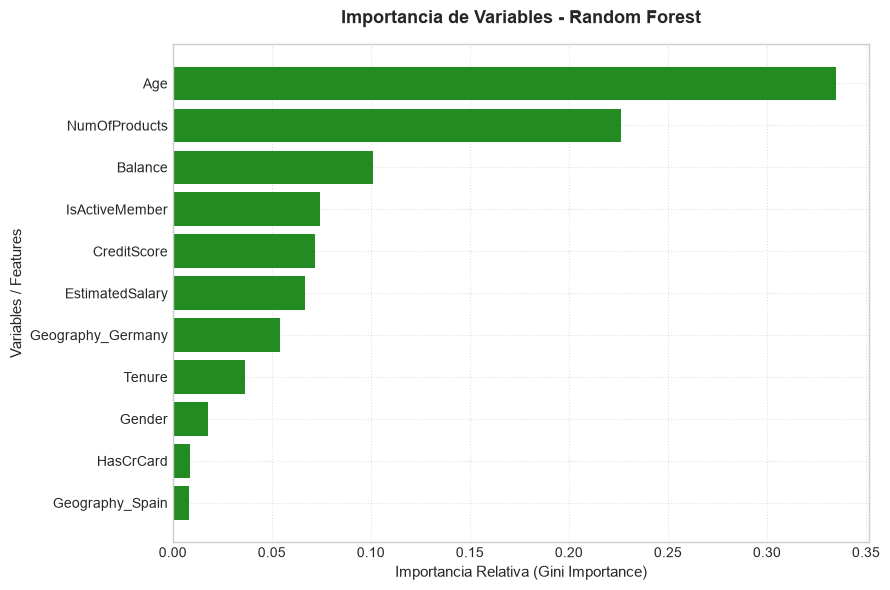

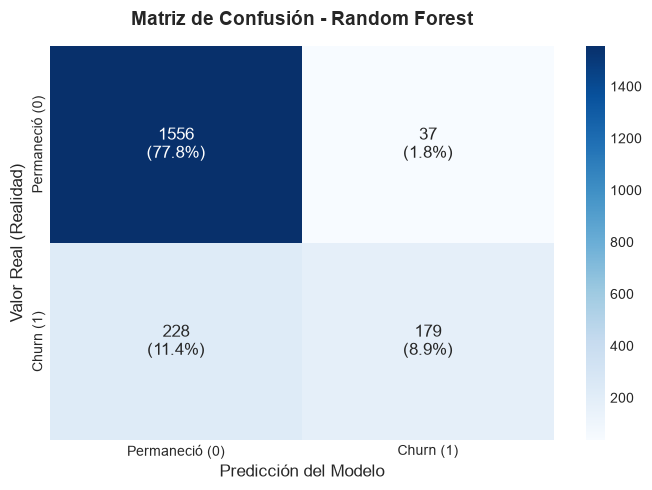

🚨 DESGLOSE DE LA MATRIZ DE CONFUSIÓN - RANDOM FOREST:
----------------------------------------------------------------------------------------------------
❗❗ Falsos Negativos   (FN):  228 (Fugas no detectadas - ERROR GRAVE)
⭕ Falsos Positivos     (FP):   37 (Falsas alarmas de churn)
✅ Verdaderos Negativos (TN): 1556 (Clientes retenidos predichos correctamente)
✅ Verdaderos Positivos (TP):  179 (Clientes en churn detectados a tiempo)


In [8]:
# 8. Finalmente, realizamos las respectivs graficas para entender el modelo y sus predicciones
# 8.1 Grafica de Importance Feature:
plt.figure(figsize=(9, 6))
plt.barh(df_importancias['Feature'], df_importancias['Importancia'], color= 'forestgreen')
plt.xlabel('Importancia Relativa (Gini Importance)', fontsize=11)
plt.ylabel('Variables / Features', fontsize=11)
plt.title('Importancia de Variables - Random Forest', fontsize=13, pad=15)
plt.grid(True, linestyle=":", alpha=0.6)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# 9. Graficamos nuestra Matriz de Confusión
random_f_mc = confusion_matrix(y_test, y_pred_random_f)

# 9.1 Hacemos toda la configuración de valores dentro de los cuadros:
labels_random_f = [f'{val_1}\n({pctj_1:.1f}%)' for val_1, pctj_1 in zip 
                    (random_f_mc.flatten(), random_f_mc.flatten() / random_f_mc.sum() * 100)]
labels_random_f = np.array(labels_random_f).reshape(2, 2)

# 9.2 Graficamos
plt.figure(figsize=(7, 5))
sns.heatmap(
    random_f_mc,
    annot= labels_random_f,
    fmt= '',
    cmap= 'Blues',
    xticklabels=['Permaneció (0)', 'Churn (1)'],
    yticklabels=['Permaneció (0)', 'Churn (1)'],
    annot_kws={'size':12},
)

plt.title('Matriz de Confusión - Random Forest', fontsize=14, pad=15)
plt.xlabel('Predicción del Modelo', fontsize=12)
plt.ylabel('Valor Real (Realidad)', fontsize=12)
plt.tight_layout()
plt.show()

# 9.3 Afinamos detalles con respecto a como interpretar la matriz de confusión:

tn_rf, fp_rf, fn_rf, tp_rf = random_f_mc.ravel()

print("🚨 DESGLOSE DE LA MATRIZ DE CONFUSIÓN - RANDOM FOREST:")
print("-" * 100)
print(f"❗❗ Falsos Negativos   (FN): {fn_rf:4d} (Fugas no detectadas - ERROR GRAVE)")
print(f"⭕ Falsos Positivos     (FP): {fp_rf:4d} (Falsas alarmas de churn)")
print(f"✅ Verdaderos Negativos (TN): {tn_rf:4d} (Clientes retenidos predichos correctamente)")
print(f"✅ Verdaderos Positivos (TP): {tp_rf:4d} (Clientes en churn detectados a tiempo)")

### 💻 3. XGBoost (PARTE 1 - Modelo Base)

**Concepto breve:** Extreme Gradient Boosting es uno de los algoritmos de Machine Learning más potentes y populares del mundo. Es una versión ultra optimizada del algoritmo de Gradient Boosting, diseñada para ser extremadamente rápida, eficiente y precisa con datos tabulares (hojas de cálculo).

1. Crea árboles de decisión de forma secuencial (uno tras otro) donde cada nuevo árbol se especializa exclusivamente en corregir los errores cometidos por el árbol anterior.
2. Para que el algoritmo no se sobresature aprendiendo de memoria o tardando demasiado, se controla usando hiperparámetros. Tales como:

- Learning Rate (Tasa de Aprendizaje): es la velocidad o el tamaño del paso con el que el modelo aprende. Cuando un nuevo árbol detecta un error del árbol anterior y propone una corrección, el learning_rate multiplica esa corrección por un número pequeño (por ejemplo, 0.1 o 0.05) antes de sumarla al modelo final. Actuando como un "freno de mano", para que el modelo se regule y no aprenda de manera "tosca", a su vez, tampoco aprenda "demasiado", ya que esto saturaria la memoria y el tiempo de rendimiento del modelo.
- Max_depth (Profundidad Máxima): es el tamaño máximo o número de pisos que puede tener cada árbol de decisión individual dentro del modelo. Controla cuántas preguntas consecutivas (divisiones) puede hacer un solo árbol para llegar a una conclusión. Es el control principal contra el sobreentrenamiento (overfitting). Esto debido a que en XGBoost, a diferencia de Random Forest, se necesitan árboles cortos y débiles, los árboles con demasiada profundidad memorizan datos en el entrenamiento (siendo excelentes en esta área), pero, fallan con datos nuevos.
- N_estimators (Número de Estimadores): es la cantidad total de árboles que se van a construir en secuencia. Actua como una cadena, donde los siguientes árboles creados por XGBoost aprenden del anterior, así sucesivamente. Trabaja de la mano con "learning_rate", ya que si la tasa de aprendizaje es muy pequeña (pasos cortos), se necesitará un n_estimators muy alto (muchos árboles) para llegar a la meta. Sin embargo, creamos demasiados árboles, el modelo puede empezar a aprender del "ruido" o errores sin sentido, degradando su precisión.
- Subsample (Fracción de filas): controla qué porcentaje de los datos (filas) se le permite ver a cada árbol individual. Ésto permite añadir aleatoridad al modelo, actuando de manera muy similar a Random Forest. Evitando overfitting.
- Colsample_bytree (Fracción de columnas): especifica el porcentaje de variables (features) que cada árbol puede utilizar. Lo que evita que el modelo dependa exclusivamente de una o dos variables súper dominantes, obligando a los árboles a encontrar patrones ocultos en las otras columnas menos obvias.
- Reg_alpha (L1) y Reg_lambda (L2) (Regularización): aplican penalizaciones matemáticas directas a las hojas de los árboles que tienen valores extremos o predicciones exageradas. "Castigando" la complejidad del modelo, reg_lambda (L2) ya esta activado por defecto y ayuda a suavizar las predicciones del modelo. en el caso de reg_alpha (L1) es recomendable en Dataset grandes, ya que tiende a aislar por completo las variables que no aportan nada útil.

### 📊 Resumen de Desempe desempeño y Diagnóstico: XGBoost (Modelo Base)

#### 1. Métricas de Evaluación
* **Accuracy (86.70%):** Mantiene una capacidad global de clasificación muy sólida (valores similares al modelo anterior).
* **Precision (78.54%):** De cada 100 clientes que el modelo predice como en riesgo de fuga, casi **79 son aciertos reales**, manteniendo un nivel de falsas alarmas bajo.
* **Recall (47.67%):** Muestra una ligera mejora frente a Random Forest (pasa de ~44% a 47.67%), logrando identificar a **194 clientes en Churn real**. Sin embargo, aún deja escapar al 52.33% de los casos.
* **F1-Score (0.5933):** Logra un mejor equilibrio global entre Precisión y Recall en comparación con la solución baseline.
* **ROC-AUC (0.8669):** Excelente capacidad de discriminación general entre ambas clases.

#### 2. Matriz de Confusión
* **Verdaderos Negativos (1,540 / 77.0%):** Alta precisión identificando a los clientes leales que no abandonarán el servicio.
* **Falsos Positivos (53 / 2.6%):** Solo 53 falsas alarmas (falsos positivos) generadas.
* **Falsos Negativos (213 / 10.7%):** Principal foco de atención a mejorar con el tuneo de hiperparámetros: 213 clientes en Churn no fueron detectados a tiempo.
* **Verdaderos Positivos (194 / 9.7%):** Detecta exitosamente a 194 clientes en riesgo de abandono.

#### 3. Importancia de Variables (Feature Importances - Gain)
* **`NumOfProducts` (27.52%):** A diferencia de Random Forest, en XGBoost la cantidad de productos contratados se convierte en el **factor número 1** determinante para predecir la cancelación del servicio.
* **`IsActiveMember` (19.82%) y `Age` (17.78%):** Conforman el segundo bloque de variables más influyentes; el nivel de actividad y la edad son altamente predictivos.

🚀Entrenamos mi XGBoost!
Modelo Entrenado Exitosamente 👍
----------------------------------------------------------------------------------------------------

MÉTRICAS DE EVALUACIÓN DE MI XGBOOST
              precision    recall  f1-score   support

    No Churn     0.8785    0.9667    0.9205      1593
       Churn     0.7854    0.4767    0.5933       407

    accuracy                         0.8670      2000
   macro avg     0.8320    0.7217    0.7569      2000
weighted avg     0.8596    0.8670    0.8539      2000

Accuracy Score: 0.8670      | 86.70% 
Precision Score: 0.7854      | 78.54% 
Recall Score: 0.4767      | 47.67% 
F1-Score: 0.5933      | 59.33% 
ROC - AUC Score: 0.8669      | 86.69% 

----------------------------------------------------------------------------------------------------
          Feature_XGB  Importancia_XGB
5       NumOfProducts         0.275167
7      IsActiveMember         0.198217
2                 Age         0.177818
9   Geography_Germany         0.1171

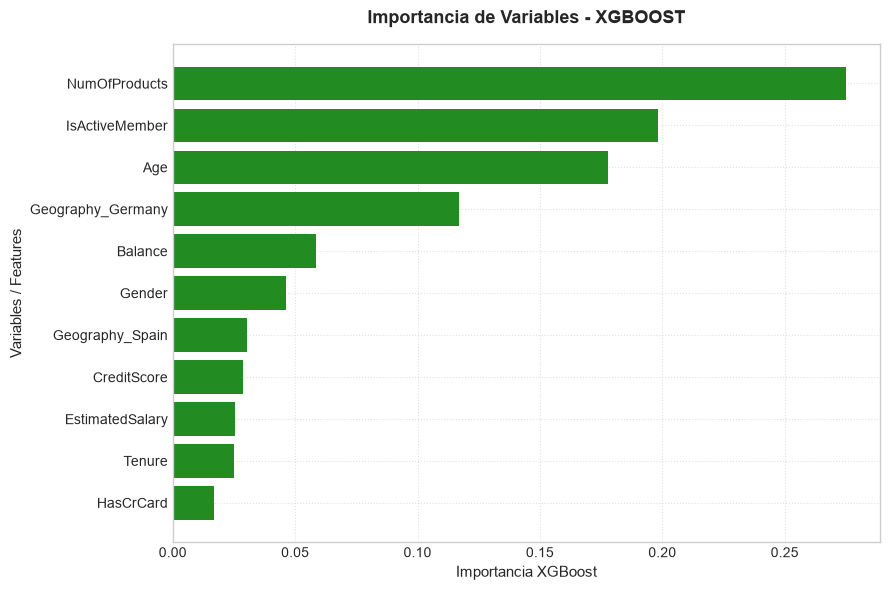

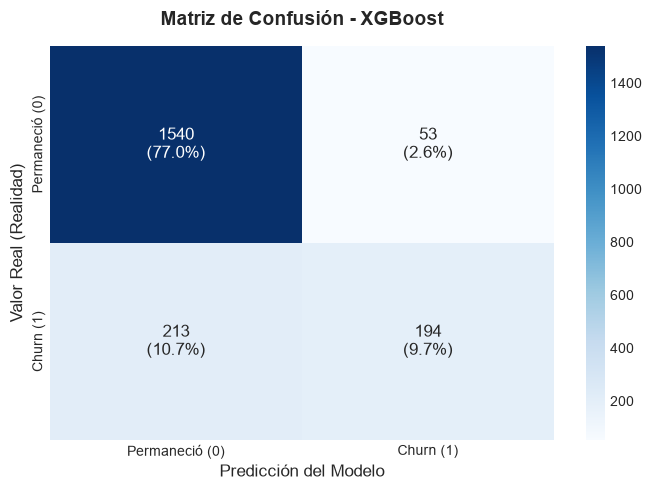

🚨 DESGLOSE DE LA MATRIZ DE CONFUSIÓN - XGBOOST:
----------------------------------------------------------------------------------------------------
❗❗ Falsos Negativos   (FN):  213 (Fugas no detectadas - ERROR GRAVE)
⭕ Falsos Positivos     (FP):   53 (Falsas alarmas de churn)
✅ Verdaderos Negativos (TN): 1540 (Clientes retenidos predichos correctamente)
✅ Verdaderos Positivos (TP):  194 (Clientes en churn detectados a tiempo)


In [9]:
# 1. Realizamos la creación de nuestro algoritmo con una configuración estandar
print("🚀Entrenamos mi XGBoost!")
xgb_base = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)

# 2. Entrenamos el modelo
xgb_base.fit(x_train_scaled, y_train)
print("Modelo Entrenado Exitosamente 👍")

# 3. Realizamos las predicciones
y_pred_xgb_base = xgb_base.predict(x_test_scaled)
y_pred_proba_xgb_base = xgb_base.predict_proba(x_test_scaled)[:, 1]

# 4. Calculamos las metricas de evalución e imprimimos
accuracy_xgb = accuracy_score(y_test, y_pred_xgb_base)
precision_xgb = precision_score(y_test, y_pred_xgb_base, pos_label=1)
recall_xgb = recall_score(y_test, y_pred_xgb_base, pos_label=1)
f1_xgb = f1_score(y_test, y_pred_xgb_base, pos_label=1)

print("-"*100)
print("\nMÉTRICAS DE EVALUACIÓN DE MI XGBOOST")
print(classification_report(y_test, y_pred_xgb_base, target_names=['No Churn', 'Churn'], digits=4))
print(f"Accuracy Score: {accuracy_xgb:.4f}      | {accuracy_xgb*100:.2f}% ")
print(f"Precision Score: {precision_xgb:.4f}      | {precision_xgb*100:.2f}% ")
print(f"Recall Score: {recall_xgb:.4f}      | {recall_xgb*100:.2f}% ")
print(f"F1-Score: {f1_xgb:.4f}      | {f1_xgb*100:.2f}% ")

# 5. Calculo de ROC - AUC e imprimimos
fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(y_test, y_pred_proba_xgb_base)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

print(f"ROC - AUC Score: {roc_auc_xgb:.4f}      | {roc_auc_xgb*100:.2f}% \n")

# 6. Visualizamos Feature Importance (aunque sea el XGBoost base)
xgboost_importancias = xgb_base.feature_importances_

xgb_base_df = pd.DataFrame({
    'Feature_XGB': x_train_scaled.columns,
    'Importancia_XGB': xgboost_importancias
}).sort_values(by= 'Importancia_XGB', ascending=False)
print("-"*100)
print(xgb_base_df)

# 7. Grafica de Feature Importance
plt.figure(figsize=(9, 6))
plt.barh(xgb_base_df['Feature_XGB'], xgb_base_df['Importancia_XGB'], color= 'forestgreen')
plt.xlabel('Importancia XGBoost', fontsize=11)
plt.ylabel('Variables / Features', fontsize=11)
plt.title('Importancia de Variables - XGBOOST', fontsize=13, pad=15)
plt.grid(True, linestyle=":", alpha=0.6)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# 8. Graficamos nuestra Matriz de Confusión
xgboost_mc = confusion_matrix(y_test, y_pred_xgb_base)

# 8.1 Hacemos toda la configuración de valores dentro de los cuadros:
labels_xgboost = [f'{val_2}\n({pctj_2:.1f}%)' for val_2, pctj_2 in zip 
                    (xgboost_mc.flatten(), xgboost_mc.flatten() / xgboost_mc.sum() * 100)]
labels_xgboost = np.array(labels_xgboost).reshape(2, 2)

# 8.2 Graficamos
plt.figure(figsize=(7, 5))
sns.heatmap(
    xgboost_mc,
    annot= labels_xgboost,
    fmt= '',
    cmap= 'Blues',
    xticklabels=['Permaneció (0)', 'Churn (1)'],
    yticklabels=['Permaneció (0)', 'Churn (1)'],
    annot_kws={'size':12},
)

plt.title('Matriz de Confusión - XGBoost', fontsize=14, pad=15)
plt.xlabel('Predicción del Modelo', fontsize=12)
plt.ylabel('Valor Real (Realidad)', fontsize=12)
plt.tight_layout()
plt.show()

# 8.3 Afinamos detalles con respecto a como interpretar la matriz de confusión:

tn_xgb, fp_xgb, fn_xgb, tp_xgb = xgboost_mc.ravel()

print("🚨 DESGLOSE DE LA MATRIZ DE CONFUSIÓN - XGBOOST:")
print("-" * 100)
print(f"❗❗ Falsos Negativos   (FN): {fn_xgb:4d} (Fugas no detectadas - ERROR GRAVE)")
print(f"⭕ Falsos Positivos     (FP): {fp_xgb:4d} (Falsas alarmas de churn)")
print(f"✅ Verdaderos Negativos (TN): {tn_xgb:4d} (Clientes retenidos predichos correctamente)")
print(f"✅ Verdaderos Positivos (TP): {tp_xgb:4d} (Clientes en churn detectados a tiempo)")

### 💻 3.1 XGBoost (PARTE 2 - Optimización de Hiperparámetros - Grid Search)
El modelo XGBoost Hiperparametrizado se configuró mediante una búsqueda sistemática (GridSearchCV con 5-Fold Cross Validation), evaluando 432 combinaciones de hiperparámetros sobre métrica de optimización ROC-AUC.

***Configuración Óptima Obtenida:***

- Max_depth: 3 (árboles de profundidad baja para controlar la complejidad y evitar sobreajuste).
- Learning_rate: 0.1 (tasa de aprendizaje equilibrada entre convergencia y velocidad).
- N_estimators: 200 (cantidad de árboles de decisión en el ensamble).
- Subsample: 0.8 y colsample_bytree: 1.0 (submuestreo del 80% de las filas por árbol para aportar aleatoriedad y robustez).
- Reg_alpha: 0.1 (regularización L1 para penalizar pesos y simplificar el modelo).
- Reg_lambda: 1 (regularización L2 por defecto).

***Variables Claves (Feature Importance por Gain):***
El análisis nativo por método Gain reveló que IsActiveMember, NumOfProducts y Age son las variables con mayor capacidad predictiva para reducir el error al clasificar a los clientes en riesgo de abandono.

### 📊 Resumen de ejecución - XGBoost Hiperparametrizado
1. Rendimiento General del Modelo: el modelo XGBoost Hiperparametrizado muestra un desempeño sumamente sólido y robusto en el conjunto de prueba:
- Accuracy (86.95%): El modelo clasifica correctamente a casi el 87% de los clientes totales.
- ROC - AUC (86.79%): Demuestra una alta capacidad de discriminación para separar la clase positiva (Churn) de la negativa (No Churn).
- F1-Score (60.39%): Alcanza un balance óptimo entre la precisión de sus predicciones y la captura real de clientes en fuga.

2. Desglose de la Matriz de Confusión y Clase Minoritaria (Churn): al analizar la capacidad de predicción sobre los clientes propensos a abandonar (Clase Churn):
- Alta Precisión (78.97%): Cuando el modelo lanza una alerta de Churn, tiene razón el 78.97% de las veces. Solo cometió 53 Falsos Positivos (2.6%), lo que evita gastar presupuesto inútilmente en incentivos de retención para clientes que no pensaban irse.
- Recall / Sensibilidad (48.89%): Logró identificar a 199 clientes en riesgo (10.0%) antes de su partida (Verdaderos Positivos). No obstante, 208 clientes pasaron desapercibidos (10.4% de Falsos Negativos), siendo este el margen principal de mejora mediante ajuste de umbral (threshold).

3. Variables de Mayor Impacto (Feature Importance): el modelo determinó que la probabilidad de abandono está conducida principalmente por 5 factores clave:
- IsActiveMember (27.39%): Ser un miembro activo en la plataforma es el predictor más fuerte para permanecer en la empresa.
- NumOfProducts (26.75%): La cantidad de productos contratados influye drásticamente en la vinculación del cliente.
- Age (22.54%): La edad del usuario representa un factor demográfico determinante en la tasa de fuga.
- Geography_Germany (17.20%): La ubicación geográfica (específicamente Alemania) muestra un comportamiento de riesgo diferenciado.
- Gender (10.46%): El género del cliente aporta al perfil de segmentación.

### 📌 Conclusión
El XGBoost Hiperparametrizado destaca por ser el modelo más preciso y confiable para evitar falsas alarmas de fuga, permitiendo un uso sumamente eficiente del presupuesto de retención. Para maximizar su impacto, se sugiere acompañarlo de una política de ajuste en el umbral de decisión para capturar un porcentaje mayor de esos Falsos Negativos.

⏳ Iniciando la búsqueda de los mejores hiperparámetros con GridSearchCV...

Parametros a probar:
    -n_estimators: [100, 200, 300]
    -max_depth: [3, 5, 7]
    -learning_rate: [0.01, 0.1, 0.2]
    -subsample: [0.8, 1.0]
    -colsample_bytree: [0.8, 1.0]
    -reg_alpha: [0, 0.1]
    -reg_lambda: [1, 10]
----------------------------------------------------------------------------------------------------
Total combinaciones realizadas en mi XGBoost Hiperparametrizado:
432

🔄 Total de ajustes (fits) con Cross Validation (cv=5): 2160
----------------------------------------------------------------------------------------------------
Fitting 5 folds for each of 432 candidates, totalling 2160 fits
👍 Grid Search completado en un rango de tiempo de: 1.96 minutos
----------------------------------------------------------------------------------------------------
🎉 HIPERPARAMETROS MAS OPTIMOS:
    - colsample_bytree: 1.0
    - learning_rate: 0.1
    - max_depth: 3
    - n_estimators: 200
    - 

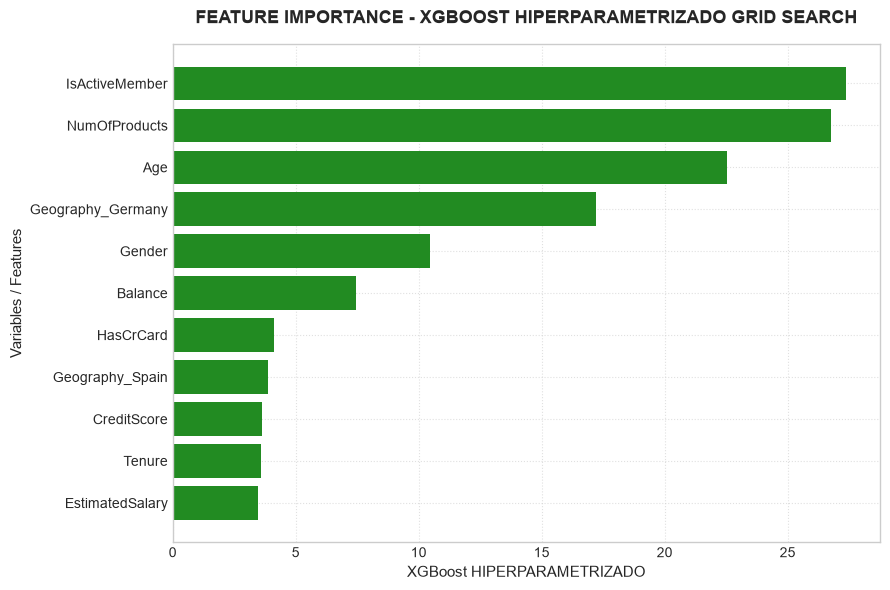

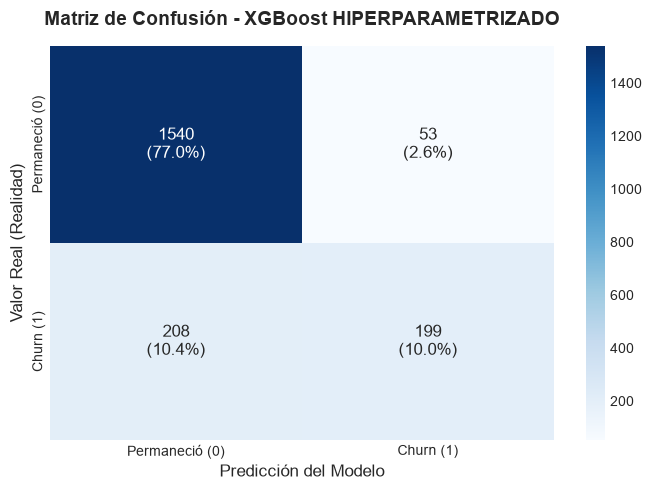

🚨 DESGLOSE DE LA MATRIZ DE CONFUSIÓN - XGBOOST HIPERPARAMETRIZADO:
----------------------------------------------------------------------------------------------------
❗❗ Falsos Negativos   (FN):  208 (Fugas no detectadas - ERROR GRAVE)
⭕ Falsos Positivos     (FP):   53 (Falsas alarmas de churn)
✅ Verdaderos Negativos (TN): 1540 (Clientes retenidos predichos correctamente)
✅ Verdaderos Positivos (TP):  199 (Clientes en churn detectados a tiempo)


In [10]:
# 1. Realizamos la busqueda de los mejores hiperparametros para nuestro XGBoost con Grid Search
print("⏳ Iniciando la búsqueda de los mejores hiperparámetros con GridSearchCV...")

param_grid_xgb = {
    'n_estimators': [100, 200, 300],    # Cantidad de árboles
    'max_depth': [3, 5, 7],             # Profundidad máxima
    'learning_rate': [0.01, 0.1, 0.2],  # Tasa de aprendizaje
    'subsample': [0.8, 1.0],            # Submuestra de filas por árbol
    'colsample_bytree': [0.8, 1.0],     # Submuestra de columnas/features por árbol
    'reg_alpha': [0, 0.1],              # L1 regularization
    'reg_lambda': [1, 10]               # L2 regularization
}

# 2. Iteramos un "for" para ver cuáles son las opciones de hiperparámetros que se configuraron a la grilla (opcional)
print("\nParametros a probar:")
for param, values in param_grid_xgb.items():
    print(f"    -{param}: {values}")
print("-"*100)

# 2.1 A su vez, vamos a imprimir la cantidad total de conbinaciones realizadas por el modelo y cross__validation (valor predeterminado por sk-learn)
total_combinaciones = np.prod([len(values) for values in param_grid_xgb.values()])

print(f"Total combinaciones realizadas en mi XGBoost Hiperparametrizado:")
print(total_combinaciones)
print(f"\n🔄 Total de ajustes (fits) con Cross Validation (cv=5): {total_combinaciones * 5}")
print("-"*100)

# 3. Configurando e instanciando el modelo con Grid Search
xgb_grid = GridSearchCV(
    estimator=xgb.XGBClassifier(
        random_state=42,
        eval_metric='logloss',
        use_label_encoder=False
    ),
    param_grid=param_grid_xgb,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc',  # Métrica de optimización
    n_jobs=-1,          # Usa todos los CPU
    verbose=2
)

# 4. Ejecución / Entrenamiento del Grid (Se toman tiempos de los diferentes entrenamientos)
import time
start_time = time.time()
xgb_grid.fit(x_train_scaled, y_train)
end_time = time.time()

print(f"👍 Grid Search completado en un rango de tiempo de: {(end_time - start_time)/60:.2f} minutos")
print("-"*100)

# 5. Mejores hiperparámetros con la función best_params
print("🎉 HIPERPARAMETROS MAS OPTIMOS:")
for param, value in xgb_grid.best_params_.items():
    print(f"    - {param}: {value}")
print("-"*100)

# 6. Seleccionamos el mejor modelo con la función best_estimator_ y realizamos las predicciones sobre este modelo
xgb_best_grid = xgb_grid.best_estimator_
y_pred_xgb_best = xgb_best_grid.predict(x_test_scaled)
y_pred_proba_xgb_best = xgb_best_grid.predict_proba(x_test_scaled)[:, 1]

# 7. Calculamos metricas, Curva ROC - AUC
accuracy_xgb_best = accuracy_score(y_test, y_pred_xgb_best)
precision_xgb_best = precision_score(y_test, y_pred_xgb_best, pos_label=1)
recall_xgb_best = recall_score(y_test, y_pred_xgb_best, pos_label=1)
f1_xgb_best = f1_score(y_test, y_pred_xgb_best, pos_label=1)

# 7.1 Imprimimos metricas
print("📌 MÉTRICAS DE EVALUACIÓN XGBOOST HIPERPARAMETRIZADO")
print(classification_report(y_test, y_pred_xgb_best, target_names=['No Churn', 'Churn'], digits=4))
print(f"Accuracy Score: {accuracy_xgb_best:.4f}      | {accuracy_xgb_best*100:.2f}% ")
print(f"Precision Score: {precision_xgb_best:.4f}      | {precision_xgb_best*100:.2f}% ")
print(f"Recall Score: {recall_xgb_best:.4f}      | {recall_xgb_best*100:.2f}% ")
print(f"F1-Score: {f1_xgb_best:.4f}      | {f1_xgb_best*100:.2f}% ")

# 7.2 Curva ROC - AUC
fpr_xgb_best, tpr_xgb_best, thresholds_xgb_best = roc_curve(y_test, y_pred_proba_xgb_best)
roc_auc_xgb_best = auc(fpr_xgb_best, tpr_xgb_best)

print(f"ROC - AUC Score: {roc_auc_xgb_best:.4f}      | {roc_auc_xgb_best*100:.2f}% \n")
print("-"*100)

# 8 Realizamos los calculos de las Features Importance con metodo Gain
importance_gain = xgb_best_grid.get_booster().get_score(importance_type='gain')
xgb_gain_feature_df = pd.DataFrame({
    'Feature': list(importance_gain.keys()),
    'Importance_Gain': list(importance_gain.values())
}).sort_values('Importance_Gain', ascending=False) 

# 8.1 Mapeo de Nombres de las columnas de los nuevos DataFrame (XGBoost cambia los nombres a F0, F1, etc)
features_name = x_train_scaled.columns.tolist()
xgb_gain_feature_df['Feature_Name'] = xgb_gain_feature_df['Feature'].apply(
    lambda x: features_name[int(x[1:])] if x[0] == 'f' else x 
)

# 8.2 Imprimimos las features importance con metodo Gain
print(xgb_gain_feature_df[['Feature_Name','Importance_Gain']].head(10))

# 8.3 Grafica Feature Importance
plt.figure(figsize=(9, 6))
plt.barh(xgb_gain_feature_df['Feature_Name'], xgb_gain_feature_df['Importance_Gain'], color= 'forestgreen')
plt.xlabel('XGBoost HIPERPARAMETRIZADO', fontsize=11)
plt.ylabel('Variables / Features', fontsize=11)
plt.title('FEATURE IMPORTANCE - XGBOOST HIPERPARAMETRIZADO GRID SEARCH', fontsize=13, pad=15)
plt.grid(True, linestyle=":", alpha=0.6)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# 9. Matriz de Confusión
best_xgboost_mc = confusion_matrix(y_test, y_pred_xgb_best)

# 9.1 Hacemos toda la configuración de valores dentro de los cuadros:
labels_xgboost_best = [f'{val_3}\n({pctj_3:.1f}%)' for val_3, pctj_3 in zip 
                    (best_xgboost_mc.flatten(), best_xgboost_mc.flatten() / best_xgboost_mc.sum() * 100)]
labels_xgboost_best = np.array(labels_xgboost_best).reshape(2, 2)

plt.figure(figsize=(7, 5))
sns.heatmap(
    best_xgboost_mc,
    annot= labels_xgboost_best,
    fmt= '',
    cmap= 'Blues',
    xticklabels=['Permaneció (0)', 'Churn (1)'],
    yticklabels=['Permaneció (0)', 'Churn (1)'],
    annot_kws={'size':12},
)

plt.title('Matriz de Confusión - XGBoost HIPERPARAMETRIZADO', fontsize=14, pad=15)
plt.xlabel('Predicción del Modelo', fontsize=12)
plt.ylabel('Valor Real (Realidad)', fontsize=12)
plt.tight_layout()
plt.show()

# 9.2 Afinamos detalles sobre el desgloce de la Matriz
tn_xgb_best, fp_xgb_best, fn_xgb_best, tp_xgb_best = best_xgboost_mc.ravel()

print("🚨 DESGLOSE DE LA MATRIZ DE CONFUSIÓN - XGBOOST HIPERPARAMETRIZADO:")
print("-" * 100)
print(f"❗❗ Falsos Negativos   (FN): {fn_xgb_best:4d} (Fugas no detectadas - ERROR GRAVE)")
print(f"⭕ Falsos Positivos     (FP): {fp_xgb_best:4d} (Falsas alarmas de churn)")
print(f"✅ Verdaderos Negativos (TN): {tn_xgb_best:4d} (Clientes retenidos predichos correctamente)")
print(f"✅ Verdaderos Positivos (TP): {tp_xgb_best:4d} (Clientes en churn detectados a tiempo)")

### 📌 COMPARACIÓN: XGBOOST BASELINE 🆚 XGBOOST HIPERPARAMETRIZADO (OPTIMIZADO)

Al comparar el modelo inicial (Baseline) con el modelo optimizado (GridSearch), se observan los siguientes hallazgos principales:

***Métrica Principal (ROC-AUC):***
El rendimiento en la curva ROC-AUC tuvo una mejora marginal de +0.10%, pasando de 86.69% en el modelo Baseline a 86.79% en el modelo optimizado. Esto confirma que el algoritmo por defecto ya capturaba con alta fidelidad los patrones del conjunto de datos.

***Impacto en Matriz de Confusión (Detección de Churn):***

- Falsos Negativos (FN): Disminuyeron en 5 casos (de 213 a 208). Esto significa que el modelo optimizado logró detectar a 5 clientes adicionales en fuga que antes pasaban desapercibidos.
- Verdaderos Positivos (TP): Se incrementaron de 194 a 199 casos correctamente detectados en Churn.
- Falsos Positivos (FP) y Verdaderos Negativos (TN): Se mantuvieron exactamente idénticos (53 y 1540 respectivamente).

***Conclusión Estratégica:***
Aunque la ganancia global en ROC-AUC parece sutil, el modelo optimizado aporta un beneficio real directo, ya que reduce los Falsos Negativos (el error más costoso) sin sacrificar la precisión ni aumentar las falsas alarmas de churn.

ROC - AUC XGBoost Baseline: 0.8669 | 86.69%
ROC - AUC XGBoost Hiperparametrizado (Optimizado): 0.8679 | 86.79%
----------------------------------------------------------------------------------------------------
Optimización entre modelos:0.0010 puntos | (0.10%).
----------------------------------------------------------------------------------------------------

Metricas Matriz de Confusión - XGBoost Baseline:
❗❗ Falsos Negativos   (FN):  213 (Fugas no detectadas - ERROR GRAVE)
⭕ Falsos Positivos     (FP):   53 (Falsas alarmas de churn)
✅ Verdaderos Negativos (TN): 1540 (Clientes retenidos predichos correctamente)
✅ Verdaderos Positivos (TP):  194 (Clientes en churn detectados a tiempo)

----------------------------------------------------------------------------------------------------

Metricas Matriz de Confusión - XGBoost Hiperparametrizado (Optimizado):
❗❗ Falsos Negativos   (FN):  208 (Fugas no detectadas - ERROR GRAVE)
⭕ Falsos Positivos     (FP):   53 (Falsas alarmas de churn)

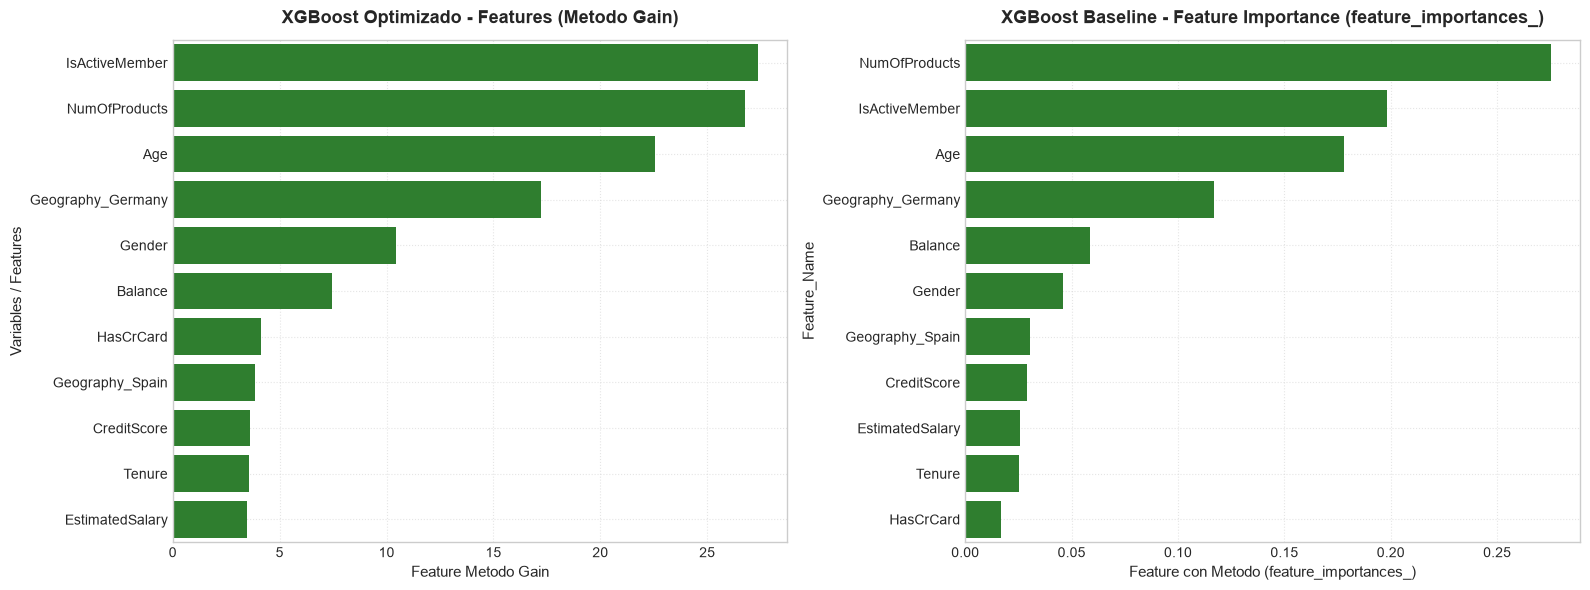

In [11]:
print(f"ROC - AUC XGBoost Baseline: {roc_auc_xgb:.4f} | {roc_auc_xgb*100:.2f}%")
print(f"ROC - AUC XGBoost Hiperparametrizado (Optimizado): {roc_auc_xgb_best:.4f} | {roc_auc_xgb_best*100:.2f}%")
print("-"*100)
print(f"Optimización entre modelos:{(roc_auc_xgb_best - roc_auc_xgb):.4f} puntos | ({(roc_auc_xgb_best - roc_auc_xgb)*100:.2f}%).")
print("-"*100)
print(f"\nMetricas Matriz de Confusión - XGBoost Baseline:")
print(f"❗❗ Falsos Negativos   (FN): {fn_xgb:4d} (Fugas no detectadas - ERROR GRAVE)")
print(f"⭕ Falsos Positivos     (FP): {fp_xgb:4d} (Falsas alarmas de churn)")
print(f"✅ Verdaderos Negativos (TN): {tn_xgb:4d} (Clientes retenidos predichos correctamente)")
print(f"✅ Verdaderos Positivos (TP): {tp_xgb:4d} (Clientes en churn detectados a tiempo)\n")
print("-"*100)
print(f"\nMetricas Matriz de Confusión - XGBoost Hiperparametrizado (Optimizado):")
print(f"❗❗ Falsos Negativos   (FN): {fn_xgb_best:4d} (Fugas no detectadas - ERROR GRAVE)")
print(f"⭕ Falsos Positivos     (FP): {fp_xgb_best:4d} (Falsas alarmas de churn)")
print(f"✅ Verdaderos Negativos (TN): {tn_xgb_best:4d} (Clientes retenidos predichos correctamente)")
print(f"✅ Verdaderos Positivos (TP): {tp_xgb_best:4d} (Clientes en churn detectados a tiempo)\n")
print("-"*100)
print(f"\nDiferencias entre modelos XGBoost Baseline - XGBoost Optimizado:")
print(f"❗❗Diferencia entre Falsos Negativos   (FN): {(fn_xgb_best - fn_xgb):4d} (Fugas no detectadas - ERROR GRAVE)")
print(f"⭕ Diferencia entre Falsos Positivos     (FP): {(fp_xgb_best - fp_xgb):4d} (Falsas alarmas de churn)")
print(f"✅ Diferencia entre Verdaderos Negativos (TN): {(tn_xgb_best - tn_xgb):4d} (Clientes retenidos predichos correctamente)")
print(f"✅ Diferencia entre Verdaderos Positivos (TP): {(tp_xgb_best - tp_xgb):4d} (Clientes en churn detectados a tiempo)\n")
print("-"*100)

# 2 Comparación visual de las Features Importance
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ------------------------------------------------------------------------------
# 1. GRÁFICO IZQUIERDO: XGBoost - Feature Importance (Gain)
# ------------------------------------------------------------------------------
sns.barplot(
    ax=axes[0],
    data=xgb_gain_feature_df.sort_values(by='Importance_Gain', ascending=False),
    x='Importance_Gain',
    y='Feature_Name',
    color='forestgreen'
)
axes[0].set_title('XGBoost Optimizado - Features (Metodo Gain)', fontsize=13, fontweight='bold', pad=12)
axes[0].set_xlabel('Feature Metodo Gain', fontsize=11)
axes[0].set_ylabel('Variables / Features', fontsize=11)
axes[0].grid(True, linestyle=":", alpha=0.5)

# ------------------------------------------------------------------------------
# 2. GRÁFICO DERECHO: XGBoost Baseline - Feature Importance (feature_importances_)
# ------------------------------------------------------------------------------
sns.barplot(
    ax=axes[1],
    data= xgb_base_df.sort_values(by='Importancia_XGB', ascending=False),
    x='Importancia_XGB',
    y='Feature_XGB',
    color='forestgreen'
)
axes[1].set_title('XGBoost Baseline - Feature Importance (feature_importances_)', fontsize=13, fontweight='bold', pad=12)
axes[1].set_xlabel('Feature con Metodo (feature_importances_)', fontsize=11)
axes[1].set_ylabel('Feature_Name', fontsize=11)
axes[1].grid(True, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()

### ✴️ PRUEBA - XGBOOST HIPERPARAMETRIZADO (Features Importances)

Solo par confirmar nuestros Features Importances realizados con el metodo Gain, con fines educativos, quiero validar si serian los mismos features con feature_importances_ (de la libreria sk-learn).

Resultados:
- 7      IsActiveMember              0.209948
- 5       NumOfProducts              0.205073
- 2                 Age              0.172785
- 9   Geography_Germany              0.131887
- 1              Gender              0.080182
- 4             Balance              0.057024
- 6           HasCrCard              0.031474
- 10    Geography_Spain              0.029663
- 0         CreditScore              0.027845
- 3              Tenure              0.027487
- 8     EstimatedSalary              0.026634

***Análisis Técnico:***

XGBoost cuenta con varios metodos para validar los features importances, dos (2) de estos metodos son Gain (Calidad) vs Weight (Cantidad).
- Que ocurre con .feature_importances_ (de Scikit-Learn): éste toma los valores de Gain y los escala de manera relativa para que la suma de todas las variables dé 1.0 (o 100%). Pero sin un nivel adecuado al detalle y control que si nos permite los metodos nativos de get_score (XGBClassifier)
- Importance_type='gain': sele conoce como Ganancia Absoluta, ya que identifica los predictores más potentes y nos muestra qué variables dirigen realmente en el modelo
- Importance_type='weight': neustra medida de frecuencia/control, nos muestra el número absoluto de veces que una variable aparece en todos los nodos de división de todos los árboles del ensamble. Identificando la complejidad con la que el modelo explora una variable
- Importance_type='cover': metodo 'Cobertura', nos muestra el número relativo de observaciones de datos que pasan por los nodos donde se utilizó esa variable. Nos dice si una variable afecta a muchos clientes o a un nicho muy pequeño.
Por ejemplo: si una variable tiene un Gain alto pero un Cover bajo, significa que es súper determinante, pero solo para un subgrupo muy reducido de clientes

### 💡 Conclusión:
1. Metodo Gain: nos muestra que las primeras tres (3) variables de Feature Importance, tiene un peso mayor (entre 20 al 25%). Lo que nos indica que éstas variables predictoras son las más potentes del modelo, y por consecuencia, su ruta de predicción.

2. Metodo normal sk-learn (feature_importance_): mejor distribuición del porcentaje en el que afectan las variables al modelo, las primeras tres (3), que coinciden con el resultado del metodo Gain, cuentan con un rango menor (entre 17 al 20%), esto nos permite entender que la captura de datos es correcta, sin embargo, se nota la falta de detalles y control.

In [12]:
# MODO PRUEBA
xgb_best_importancias = xgb_best_grid.feature_importances_
xgb_best_grid_df = pd.DataFrame({
    'Feature_XGB_BEST': x_train_scaled.columns,
    'Importancia_XGB_BEST': xgb_best_importancias
}).sort_values(by='Importancia_XGB_BEST', ascending=False)

print("-"*100)
print(xgb_best_grid_df)

----------------------------------------------------------------------------------------------------
     Feature_XGB_BEST  Importancia_XGB_BEST
7      IsActiveMember              0.209948
5       NumOfProducts              0.205073
2                 Age              0.172785
9   Geography_Germany              0.131887
1              Gender              0.080182
4             Balance              0.057024
6           HasCrCard              0.031474
10    Geography_Spain              0.029663
0         CreditScore              0.027845
3              Tenure              0.027487
8     EstimatedSalary              0.026634


### 💻 4 LightGBM - Optimizado para Velocidad

***Concepto breve:***
LightGBM (Light Gradient Boosting Machine) es un algoritmo de Machine Learning de código abierto desarrollado por Microsoft. Al igual que XGBoost, pertenece a la familia de los algoritmos de Gradient Boosting (creación de árboles en secuencia para corregir errores anteriores). Su nombre "Light" (Ligero), se debe a que fue diseñado específicamente para solucionar el mayor problema de XGBoost en sus inicios: el alto consumo de tiempo y memoria RAM cuando se trabaja con bases de datos gigantescas (de millones de filas).
💡Resultado: Árboles más profundos pero con menos nodos.

***Aplicaciones para este proyecto:***
- Optimización de velocidad (Leaf-wise vs Level-wise): A diferencia de XGBoost o Random Forest (que crecen nivel por nivel o de forma simétrica), LightGBM crece por hoja (Leaf-wise). Busca la hoja que más reduzca la pérdida (loss) y divide esa hoja específica, haciéndolo increíblemente más rápido en datasets grandes.

***Parámetros específicos clave:***
1. Num_leaves: Controla la complejidad del árbol. Un valor alto aprende más, pero puede causar overfitting.
2. Min_data_in_leaf (o min_child_samples en la API de Scikit-Learn): Define el número mínimo de registros en una hoja para evitar sobreajuste.
3. Max_depth: Limita la profundidad para controlar el árbol junto con num_leaves.

- Categorical feature handling: LightGBM puede manejar variables categóricas de forma nativa mediante codificación basada en histogramas de Fisher (mucho más rápida e informativa que aplicar One-Hot Encoding). NO SERÁ ÚTILIZADO PARA ÉSTE AVANCE, YA QUE TODAS LAS COLUMNAS SE ENCUENTRAN ESCALADAS, CATEGORIZADAS, Y ORGANIZADAS POR HABERSE UTILIZADO EN EL ENTRENAMIENTO DE OTROS MODELOS.

### ⚡ Resumen Ejecutivo: LightGBM
1. Rendimiento General del Modelo: el modelo LightGBM destaca por ser el algoritmo más agresivo y eficaz en la captura de clientes en riesgo de abandono dentro de la comparativa:
- Accuracy (86.40%): Mantiene una tasa global de aciertos muy alta en la muestra evaluada.
- ROC - AUC (85.62%): Presenta una sólida separación global entre los clientes que permanecen y los que abandonan.
- F1-Score (59.76%): Ofrece una relación sumamente competitiva entre la captura de fugas y la precisión de sus predicciones.

2. Desglose de la Matriz de Confusión y Clase Minoritaria (Churn): al poner foco en la detección de la clase positiva (Churn):
- Máximo Recall / Sensibilidad (49.63%): Es el líder absoluto de la comparativa en esta métrica. Logró detectar 202 clientes en riesgo (10.1%), reduciendo los Falsos Negativos a solo 205 (10.2%) (el error más bajo entre todos los modelos evaluados).
- Precisión (75.09%): Cuando predice un abandono, acierta el 75.09% de las veces. Solo registra 67 Falsos Positivos (3.4%), lo que mantiene un margen de alerta bastante seguro sin desperdiciar excesivo presupuesto.

3. Variables de Mayor Impacto (Feature Importance): a diferencia de otros árboles, LightGBM priorizó un conjunto más amplio de variables cuantitativas para construir sus decisiones:
- Age (5,649.22): La edad es, por un amplio margen, el factor más determinante para este modelo.
- NumOfProducts (4,490.40): La cantidad de productos contratados es el segundo pilar de predicción.
- Balance (2,982.69): El saldo en cuenta toma un rol protagonista en las decisiones de fuga.
- CreditScore (2,116.56): El puntaje crediticio influye activamente en la segmentación del riesgo.
- EstimatedSalary (2,064.13): El salario estimado complementa el perfil financiero del usuario.

### 📌 Conclusión para el Reporte
LightGBM se corona como el modelo estrella para la detección temprana de Churn, ya que logra rescatar a la mayor cantidad de clientes en riesgo (mayor Recall) con la menor cantidad de fugas desapercibidas. Es la recomendación número uno si la prioridad de la empresa es minimizar a toda costa la pérdida de usuarios.

💪 Entrenando LightGBM
👍 Entrenamiento completado en: 0.00 minutos
----------------------------------------------------------------------------------------------------
📌 MÉTRICAS DE EVALUACIÓN LIGHTGBM
              precision    recall  f1-score   support

    No Churn     0.8816    0.9579    0.9182      1593
       Churn     0.7509    0.4963    0.5976       407

    accuracy                         0.8640      2000
   macro avg     0.8163    0.7271    0.7579      2000
weighted avg     0.8550    0.8640    0.8529      2000

Accuracy Score: 0.8640      | 86.40% 
Precision Score: 0.7509      | 75.09% 
Recall Score: 0.4963      | 49.63% 
F1-Score: 0.5976      | 59.76% 
ROC - AUC Score: 0.8562      | 85.62% 

----------------------------------------------------------------------------------------------------
          Feature_LGB  Importancia_LGB
2                 Age      5649.215621
5       NumOfProducts      4490.400318
4             Balance      2982.689777
0         CreditScore      211

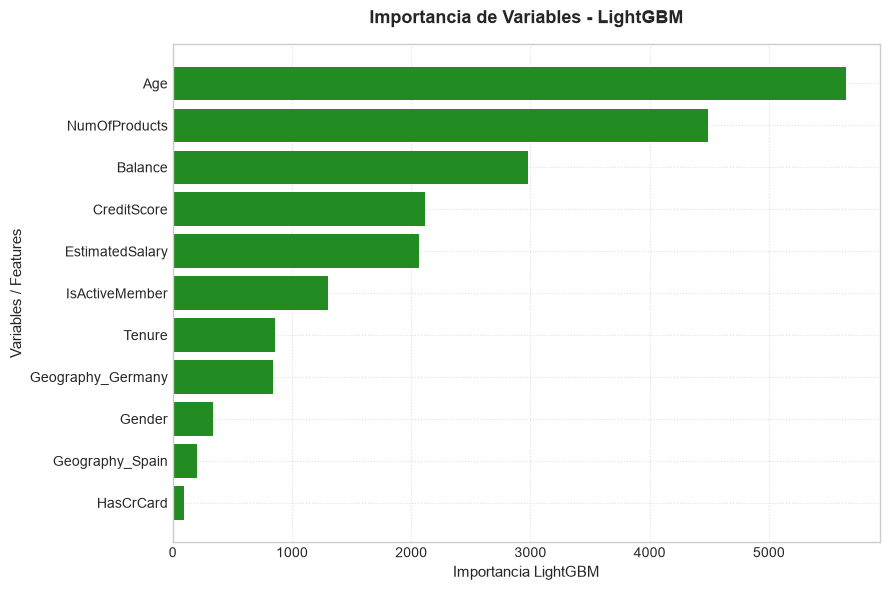

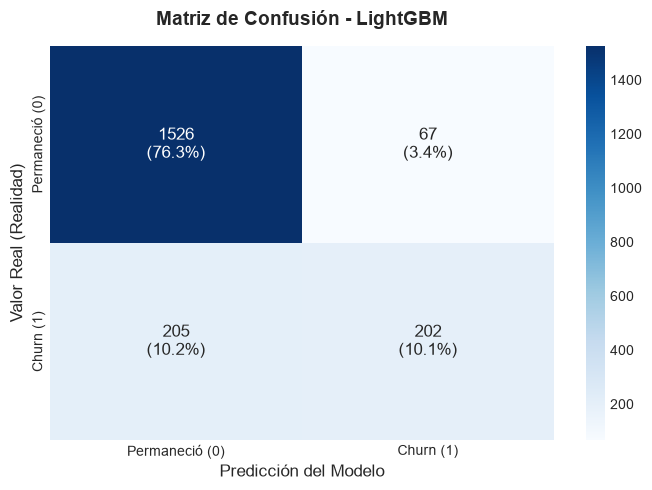

🚨 DESGLOSE DE LA MATRIZ DE CONFUSIÓN - LIGHTGBM:
----------------------------------------------------------------------------------------------------
❗❗ Falsos Negativos   (FN):  205 (Fugas no detectadas - ERROR GRAVE)
⭕ Falsos Positivos     (FP):   67 (Falsas alarmas de churn)
✅ Verdaderos Negativos (TN): 1526 (Clientes retenidos predichos correctamente)
✅ Verdaderos Positivos (TP):  202 (Clientes en churn detectados a tiempo)


In [13]:
# 1. Entrenando LightGBM
print("💪 Entrenando LightGBM")

# 1.1 Configuración optimizada para velocidad
lgb_model = lgb.LGBMClassifier(
    n_estimators=200,
    num_leaves=31,             # 2^5 - 1 (max_depth=5)
    max_depth=5,
    learning_rate=0.1,
    min_child_samples=20,      # Evita overfitting
    colsample_bytree=0.8,      # Random feature selection
    subsample=0.8,             # Random sample selection
    subsample_freq=5,          # Frequency of bagging
    reg_alpha=0.1,             # L1 regularization
    reg_lambda=1.0,            # L2 regularization
    random_state=42,
    n_jobs=-1,
    verbose=-1                 # Silencioso
)

# Se toma el tiempo para evaluar cuanto demora el entrenamiento
start_time_lgb = time.time()
lgb_model.fit(x_train_scaled, y_train)
end_time_lgb = time.time()

print(f"👍 Entrenamiento completado en: {(end_time_lgb - start_time_lgb)/60:.2f} minutos")
print("-"*100)

# 1.2 Predicciones del modelo
y_pred_lgb = lgb_model.predict(x_test_scaled)
y_pred_proba_lgb = lgb_model.predict_proba(x_test_scaled)[:, 1]

# 2. Métricas de Evaluación, curva ROC - AUC
accuracy_lgb = accuracy_score(y_test, y_pred_lgb)
precision_lgb = precision_score(y_test, y_pred_lgb, pos_label=1)
recall_lgb = recall_score(y_test, y_pred_lgb, pos_label=1)
f1_lgb = f1_score(y_test, y_pred_lgb, pos_label=1)

print("📌 MÉTRICAS DE EVALUACIÓN LIGHTGBM")
print(classification_report(y_test, y_pred_lgb, target_names=['No Churn', 'Churn'], digits=4))
print(f"Accuracy Score: {accuracy_lgb:.4f}      | {accuracy_lgb*100:.2f}% ")
print(f"Precision Score: {precision_lgb:.4f}      | {precision_lgb*100:.2f}% ")
print(f"Recall Score: {recall_lgb:.4f}      | {recall_lgb*100:.2f}% ")
print(f"F1-Score: {f1_lgb:.4f}      | {f1_lgb*100:.2f}% ")

# 2.1 Curva ROC - AUC
fpr_lgb, tpr_lgb, thresholds_lgb = roc_curve(y_test, y_pred_proba_lgb)
roc_auc_lgb = auc(fpr_lgb, tpr_lgb)

print(f"ROC - AUC Score: {roc_auc_lgb:.4f}      | {roc_auc_lgb*100:.2f}% \n")
print("-"*100)

# 3. Features Importances
importances_lgb_df = pd.DataFrame({
    'Feature_LGB': x_train_scaled.columns,
    'Importancia_LGB': lgb_model.booster_.feature_importance(importance_type='gain')
}).sort_values('Importancia_LGB', ascending=False)

print(importances_lgb_df)

# 4. Graficamos Features Importances y Matriz de Confusión
plt.figure(figsize=(9, 6))
plt.barh(importances_lgb_df['Feature_LGB'], importances_lgb_df['Importancia_LGB'], color= 'forestgreen')
plt.xlabel('Importancia LightGBM', fontsize=11)
plt.ylabel('Variables / Features', fontsize=11)
plt.title('Importancia de Variables - LightGBM', fontsize=13, pad=15)
plt.grid(True, linestyle=":", alpha=0.6)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# 4.1 Graficamos nuestra Matriz de Confusión
lgb_mc = confusion_matrix(y_test, y_pred_lgb)

# 4.2 Hacemos toda la configuración de valores dentro de los cuadros:
labels_lgb = [f'{val_4}\n({pctj_4:.1f}%)' for val_4, pctj_4 in zip 
                    (lgb_mc.flatten(), lgb_mc.flatten() / lgb_mc.sum() * 100)]
labels_lgb = np.array(labels_lgb).reshape(2, 2)

# 4.3 Graficamos
plt.figure(figsize=(7, 5))
sns.heatmap(
    lgb_mc,
    annot= labels_lgb,
    fmt= '',
    cmap= 'Blues',
    xticklabels=['Permaneció (0)', 'Churn (1)'],
    yticklabels=['Permaneció (0)', 'Churn (1)'],
    annot_kws={'size':12},
)

plt.title('Matriz de Confusión - LightGBM', fontsize=14, pad=15)
plt.xlabel('Predicción del Modelo', fontsize=12)
plt.ylabel('Valor Real (Realidad)', fontsize=12)
plt.tight_layout()
plt.show()

# 4.4 Afinamos detalles con respecto a como interpretar la matriz de confusión:
tn_lgb, fp_lgb, fn_lgb, tp_lgb = lgb_mc.ravel()

print("🚨 DESGLOSE DE LA MATRIZ DE CONFUSIÓN - LIGHTGBM:")
print("-" * 100)
print(f"❗❗ Falsos Negativos   (FN): {fn_lgb:4d} (Fugas no detectadas - ERROR GRAVE)")
print(f"⭕ Falsos Positivos     (FP): {fp_lgb:4d} (Falsas alarmas de churn)")
print(f"✅ Verdaderos Negativos (TN): {tn_lgb:4d} (Clientes retenidos predichos correctamente)")
print(f"✅ Verdaderos Positivos (TP): {tp_lgb:4d} (Clientes en churn detectados a tiempo)")

### ✴️ PRUEBA - LightGBM (Features Importances)

Confirmamos cuales son las features de mayor peso para nuestro modelo LightGBM. No obstante, ahora, quiero visualizar cuántas veces se seleccionó una variable para hacer un corte en los árboles. Esto lo realizaremos canculando las features del modelo con feature_importances_

Resultados:
- 8     EstimatedSalary               861
- 0         CreditScore               827
- 4             Balance               737
- 2                 Age               608
- 3              Tenure               370
- 5       NumOfProducts               204
- 9   Geography_Germany               114
- 7      IsActiveMember                98
- 1              Gender                82
- 10    Geography_Spain                68
- 6           HasCrCard                32

***Análisis Técnico:***

- Importancia por Frecuencia/Split (feature_importances_): Mide la cantidad de veces que una variable es seleccionada para dividir un nodo en los árboles.

1. Hallazgo: Variables continuas con alta densidad de valores únicos como EstimatedSalary (861 splits) y CreditScore (827 splits) encabezan el ranking. Esto ocurre porque el algoritmo encuentra múltiples puntos de corte continuos para refinar las ramas.

- Importancia por Ganancia (importance_type='gain'): Mide el aporte real en la reducción del error (pérdida) del modelo cada vez que se usa una variable.

1. Hallazgo: Variables como Age, NumOfProducts e IsActiveMember demuestran ser los verdaderos factores determinantes del Churn. Aunque se dividen en menos ocasiones, cada corte que realizan genera un impacto decisivo en la clasificación.

### 💡 Conclusión:
Mientras que el enfoque por Split ayuda a entender la estructura y complejidad con la que el modelo explora el espacio de características, el enfoque por Gain resulta ser bastante interpretable para el negocio, ya que aísla las variables con mayor poder predictivo sobre la fuga de clientes.

In [14]:
# 1 Features Importances - Metodo feature_importance_
feature_lgb_df = pd.DataFrame({
    'Feature_LGB_': x_train_scaled.columns,
    'Importancia_LGB_':  lgb_model.feature_importances_
}).sort_values('Importancia_LGB_', ascending=False)

print("Feature con Metodo feature_importance_")
print("Para medir cuantas veces una de las variables 'corto' en los árboles")
print(feature_lgb_df)

Feature con Metodo feature_importance_
Para medir cuantas veces una de las variables 'corto' en los árboles
         Feature_LGB_  Importancia_LGB_
8     EstimatedSalary               861
0         CreditScore               827
4             Balance               737
2                 Age               608
3              Tenure               370
5       NumOfProducts               204
9   Geography_Germany               114
7      IsActiveMember                98
1              Gender                82
10    Geography_Spain                68
6           HasCrCard                32


### 💻 5. CatBoost (Especialista en Variables Categóricas)

***Concepto Breve:***
Es un algoritmo de Machine Learning de código abierto de la empresa Yandex. Al igual que XGBoost y LightGBM, pertenece a la familia de Gradient Boosting (árboles secuenciales que corrigen los errores de los anteriores). Como lo indica su nombre "Cat", fue diseñado específicamente para ser el rey indiscutible de la industria al trabajar con variables categóricas (columnas de texto como ciudades, géneros, marcas o tipos de tarjetas), sin necesidad de utilizar one-hot encoding.

***Recordatorio:***
Nuestro Dataset ya cuenta las variables codificadas. No obstante igual entrenaremos CatBoost

### 📊 1. Métricas Globales y Capacidad Predictiva
- ROC-AUC Score (86.42%) y Accuracy (86.85%): El modelo demuestra un buen poder global de discriminación entre clientes que permanecen y clientes en Churn.
- Precision de Churn (77.91%): Muy alta efectividad cuando el modelo lanza una alerta. Casi 8 de cada 10 clientes identificados como fuga realmente se van a ir, lo que evita gastar recursos de retención en clientes falsamente identificados.
- Recall de Churn (49.39%): Logra detectar la mitad de las fugas reales (201 de 407 clientes en Churn).

### 🚨 2. Desgloce de la Matriz de Confusión
- Verdaderos Negativos (TN): 1,536 clientes (76.8%) retenidos e identificados correctamente.
- Verdaderos Positivos (TP): 201 clientes (10.1%) en Churn detectados a tiempo para campañas de fidelización.
- Falsos Positivos (FP): Apenas 57 clientes (2.9%) marcados por error como Churn (falsas alarmas muy bajas).
- Falsos Negativos (FN): 206 clientes (10.3%) que se fugaron sin que el modelo lograra prevenirlos (área clave de mejora mediante balanceo de clases o tuning).

### 💡 3. Variables Clave (Feature Importance)
- CatBoost identificó que más del 41% de la decisión del modelo depende de solo dos factores:
- NumOfProducts (21.37%): La cantidad de productos contratados es el factor principal de separación.
- Age (20.12%): La edad del cliente es la segunda variable más determinante.
- Balance (13.22%) y CreditScore (10.11%): Completan el grupo de variables cuantitativas con mayor impacto.

CatBoost es un modelo excelente para manera variables categoricas
Sin embargo, para fines de seguimiento, y de acuerdo a las otras solicitudes del Avance 2
-----EN ESTE MODELO NO HABRÁN VARIABLES CATOGORICAS.-----
Esto es debido a que se esta utilzando el mismo Dataset para entrenar los diferentes modelos aqui probados
----------------------------------------------------------------------------------------------------
🚀 Entrenando CatBoost...
Entrenamiento finalizado en 0.79 segundos
📌 MÉTRICAS DE EVALUACIÓN CATBOOST
              precision    recall  f1-score   support

    No Churn     0.8817    0.9642    0.9211      1593
       Churn     0.7791    0.4939    0.6045       407

    accuracy                         0.8685      2000
   macro avg     0.8304    0.7290    0.7628      2000
weighted avg     0.8609    0.8685    0.8567      2000

Accuracy Score: 0.8685      | 86.85% 
Precision Score: 0.7791      | 77.91% 
Recall Score: 0.4939      | 49.39% 
F1-Score: 0.6045      | 60.45% 
ROC -

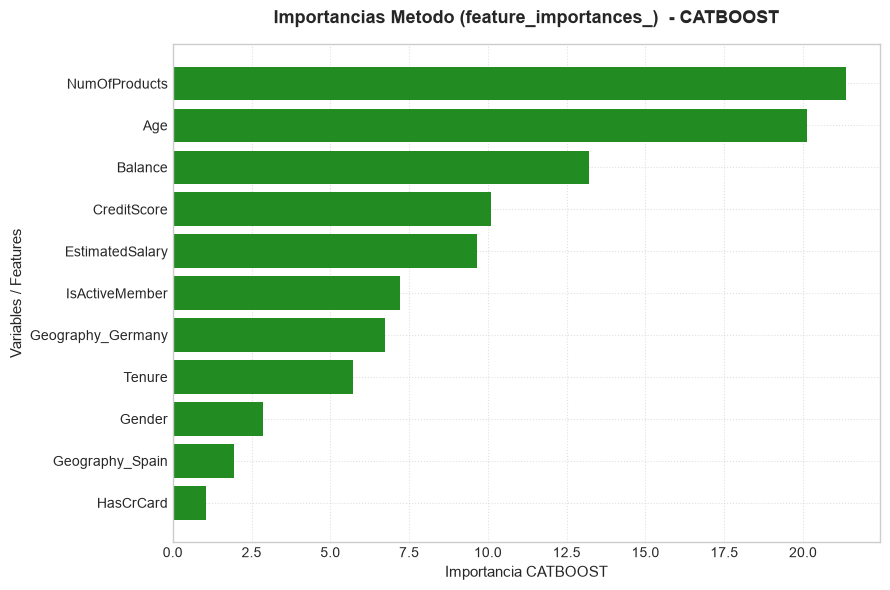

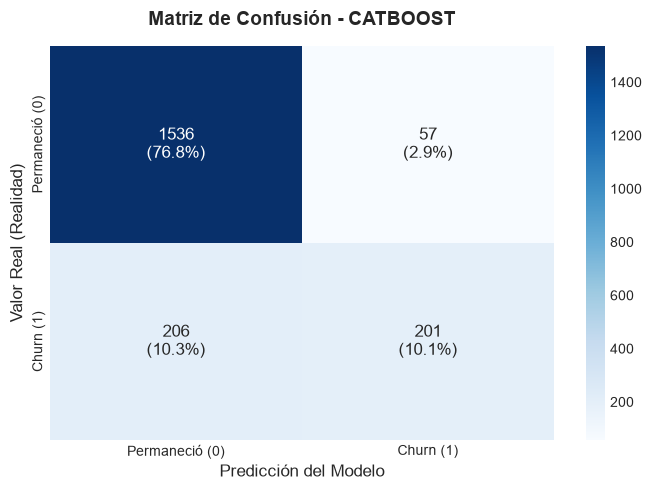

🚨 DESGLOSE DE LA MATRIZ DE CONFUSIÓN - XGBOOST:
----------------------------------------------------------------------------------------------------
❗❗ Falsos Negativos   (FN):  206 (Fugas no detectadas - ERROR GRAVE)
⭕ Falsos Positivos     (FP):   57 (Falsas alarmas de churn)
✅ Verdaderos Negativos (TN): 1536 (Clientes retenidos predichos correctamente)
✅ Verdaderos Positivos (TP):  201 (Clientes en churn detectados a tiempo)


In [15]:
# 1. Entrenando el modelo CatBoost y tomando cuanto tiempo demora el entrenamiento
print("CatBoost es un modelo excelente para manera variables categoricas")
print("Sin embargo, para fines de seguimiento, y de acuerdo a las otras solicitudes del Avance 2")
print("-----EN ESTE MODELO NO HABRÁN VARIABLES CATOGORICAS.-----")
print("Esto es debido a que se esta utilzando el mismo Dataset para entrenar los diferentes modelos aqui probados")
print("-"*100)

print("🚀 Entrenando CatBoost...")
catboost_model = CatBoostClassifier(
    iterations=200,
    depth=6,
    learning_rate=0.1,
    l2_leaf_reg=3,         # Regularización L2
    random_state=42,
    verbose=False          # Silencioso
)

start_time_cat = time.time() 
catboost_model.fit(x_train_scaled, y_train)
end_time_cat = time.time()
print(f"Entrenamiento finalizado en {end_time_cat - start_time_cat:.2f} segundos")

# 2. Predicciones del modelo
y_pred_cat = catboost_model.predict(x_test_scaled)
y_pred_proba_cat = catboost_model.predict_proba(x_test_scaled)[:, 1]

# 3. Calculamos métricas, Curva ROC - AUC
accuracy_cat = accuracy_score(y_test, y_pred_cat)
precision_cat = precision_score(y_test, y_pred_cat, pos_label=1)
recall_cat = recall_score(y_test, y_pred_cat, pos_label=1)
f1_cat = f1_score(y_test, y_pred_cat, pos_label=1)

# 3.1 Imprimimos metricas
print("📌 MÉTRICAS DE EVALUACIÓN CATBOOST")
print(classification_report(y_test, y_pred_cat, target_names=['No Churn', 'Churn'], digits=4))
print(f"Accuracy Score: {accuracy_cat:.4f}      | {accuracy_cat*100:.2f}% ")
print(f"Precision Score: {precision_cat:.4f}      | {precision_cat*100:.2f}% ")
print(f"Recall Score: {recall_cat:.4f}      | {recall_cat*100:.2f}% ")
print(f"F1-Score: {f1_cat:.4f}      | {f1_cat*100:.2f}% ")

# 3.2 Curva ROC - AUC
fpr_cat, tpr_xgb_cat, thresholds_cat = roc_curve(y_test, y_pred_proba_cat)
roc_auc_cat = auc(fpr_cat, tpr_xgb_cat)

print(f"ROC - AUC Score: {roc_auc_cat:.4f}      | {roc_auc_cat*100:.2f}% \n")
print("-"*100)

# 4. Calculamos features importance y Matriz de Confusión
cat_modelo_df = pd.DataFrame({
    'Feature_CAT': x_train_scaled.columns,
    'Importancia_CAT': catboost_model.feature_importances_
}).sort_values(by= 'Importancia_CAT', ascending=False)
print(cat_modelo_df)
print("-"*100)

# 4.1 Grafica de Feature Importance
plt.figure(figsize=(9, 6))
plt.barh(cat_modelo_df['Feature_CAT'], cat_modelo_df['Importancia_CAT'], color= 'forestgreen')
plt.xlabel('Importancia CATBOOST', fontsize=11)
plt.ylabel('Variables / Features', fontsize=11)
plt.title('Importancias Metodo (feature_importances_)  - CATBOOST', fontsize=13, pad=15)
plt.grid(True, linestyle=":", alpha=0.6)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# 4.2 Graficamos nuestra Matriz de Confusión
cat_mc = confusion_matrix(y_test, y_pred_cat)

# 4.3 Hacemos toda la configuración de valores dentro de los cuadros:
labels_cat = [f'{val_5}\n({pctj_5:.1f}%)' for val_5, pctj_5 in zip 
                    (cat_mc.flatten(), cat_mc.flatten() / cat_mc.sum() * 100)]
labels_cat = np.array(labels_cat).reshape(2, 2)

# 4.4 Graficamos
plt.figure(figsize=(7, 5))
sns.heatmap(
    cat_mc,
    annot= labels_cat,
    fmt= '',
    cmap= 'Blues',
    xticklabels=['Permaneció (0)', 'Churn (1)'],
    yticklabels=['Permaneció (0)', 'Churn (1)'],
    annot_kws={'size':12},
)

plt.title('Matriz de Confusión - CATBOOST', fontsize=14, pad=15)
plt.xlabel('Predicción del Modelo', fontsize=12)
plt.ylabel('Valor Real (Realidad)', fontsize=12)
plt.tight_layout()
plt.show()

# 4.5 Afinamos detalles con respecto a como interpretar la matriz de confusión:

tn_cat, fp_cat, fn_cat, tp_cat = cat_mc.ravel()

print("🚨 DESGLOSE DE LA MATRIZ DE CONFUSIÓN - XGBOOST:")
print("-" * 100)
print(f"❗❗ Falsos Negativos   (FN): {fn_cat:4d} (Fugas no detectadas - ERROR GRAVE)")
print(f"⭕ Falsos Positivos     (FP): {fp_cat:4d} (Falsas alarmas de churn)")
print(f"✅ Verdaderos Negativos (TN): {tn_cat:4d} (Clientes retenidos predichos correctamente)")
print(f"✅ Verdaderos Positivos (TP): {tp_cat:4d} (Clientes en churn detectados a tiempo)")

### 💻 6. Stacking - Ensamble de los Mejores Modelos 🤝

***Concepto Breve:***
Stacking es una técnica avanzada de ensemble que combina múltiples modelos de forma inteligente. Cuenta con una arquitectura de dos (2) niveles:

-Nivel uno (1): Base Learners -> los modelos a seleccionar para el ensamble
-Nivel dos(2): Meta-Learner -> es una Regresión Logística con regularización ([Pred1, Pred2, Pred3] → [Regresión Logística] → Predicción Final). El meta-learner aprende ***cuándo confiar en cada modelo.***

***❌ Problema:***
Es propenso a generar overfitting, por eso se debe usar **Cross-Validation** para generar predicciones.

### 📊 1. Desempeño General y Capacidad Predictiva
- Accuracy (86.95%): El ensamble alcanza una precisión global excelente, superando ligeramente la mayoría de los modelos individuales.
- ROC-AUC (86.72%): Muestra un altísimo poder para distinguir entre clientes estables y en riesgo de abandono.
- Precision de Churn (78.97%): Casi 8 de cada 10 clientes marcados por el Stacking realmente abandonarán la empresa. Esto garantiza una alta eficiencia en campañas comerciales, reduciendo el gasto publicitario en falsas alarmas.
- Recall de Churn (48.89%): Logra capturar prácticamente la mitad de las fugas totales de la base de prueba.

### 🚨 2. Diagnóstico de la Matriz de Confusión
- Verdaderos Negativos (TN): 1,540 clientes (77.0%) correctamente identificados como clientes que permanecen.
- Verdaderos Positivos (TP): 199 clientes (10.0%) identificados a tiempo en situación de Churn.
- Falsos Positivos (FP): Solo 53 clientes (2.6%), representando una tasa de error de falsa alarma sumamente baja.
- Falsos Negativos (FN): 208 clientes (10.4%) que se fugaron sin ser detectados.

### ⚖️ 3. Importancia y Aporte de los Modelos Base (Meta-Learner)
La Regresión Logística del Nivel 2 aprendió a ponderar los modelos base según su confiabilidad individual:
- XGBoost (Predominante): Obtuvo el coeficiente más alto, convirtiéndose en la columna vertebral del ensamble.
- CatBoost (Soporte Fuerte): Aporta un peso muy elevado, complementando perfectamente las predicciones de XGBoost.
- LightGBM (Aporte Residual): Mantiene un coeficiente bajo, actuando como un corrector secundario en casos limítrofes.

### 🏆 4. Comparativa: Stacking vs. Modelos Individuales
El Stacking (0.8672 ROC-AUC / 86.95% Accuracy) logra combinar la estabilidad de CatBoost y la precisión de XGBoost, posicionándose en el pico más alto de rendimiento del proyecto, superando por unos puntos a Random Forest y LightGBM.

Diseño selecciondo para nuestro Asamblador:
Modelo XGBoost - LightGBM - CatBoost
----------------------------------------------------------------------------------------------------
¡Modelos Base (Nivel 1)!:
  - xgboost
  - lightgbm
  - catboost
Nivel 2 completado con exito
Entrenamiento puede durar algunos minutos.
Ensamble Stacking entrenado en 0.05 minutos
----------------------------------------------------------------------------------------------------
📌 MÉTRICAS DE EVALUACIÓN STACKING CLASSIFIER
              precision    recall  f1-score   support

    No Churn     0.8810    0.9667    0.9219      1593
       Churn     0.7897    0.4889    0.6039       407

    accuracy                         0.8695      2000
   macro avg     0.8353    0.7278    0.7629      2000
weighted avg     0.8624    0.8695    0.8572      2000

Accuracy Score: 0.8695      | 86.95% 
Precision Score: 0.7897      | 78.97% 
Recall Score: 0.4889      | 48.89% 
F1-Score: 0.6039      | 60.39% 
ROC - AUC Score: 0.8

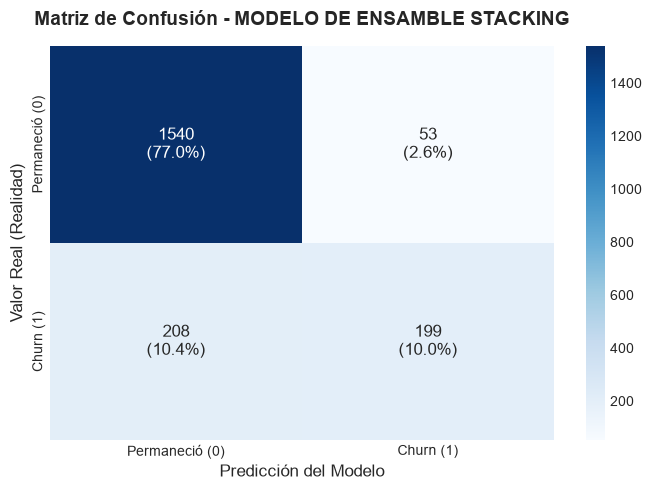

🚨 DESGLOSE DE LA MATRIZ DE CONFUSIÓN - STACKING:
----------------------------------------------------------------------------------------------------
❗❗ Falsos Negativos   (FN):  208 (Fugas no detectadas - ERROR GRAVE)
⭕ Falsos Positivos     (FP):   53 (Falsas alarmas de churn)
✅ Verdaderos Negativos (TN): 1540 (Clientes retenidos predichos correctamente)
✅ Verdaderos Positivos (TP):  199 (Clientes en churn detectados a tiempo)
----------------------------------------------------------------------------------------------------
⚖️ PESOS Y CONFIANZA ASIGNADOS POR EL META-LEARNER:
Modelo_Base  Peso_MetaLearner
    XGBoost          2.937623
   CatBoost          2.675653
   LightGBM          0.238283


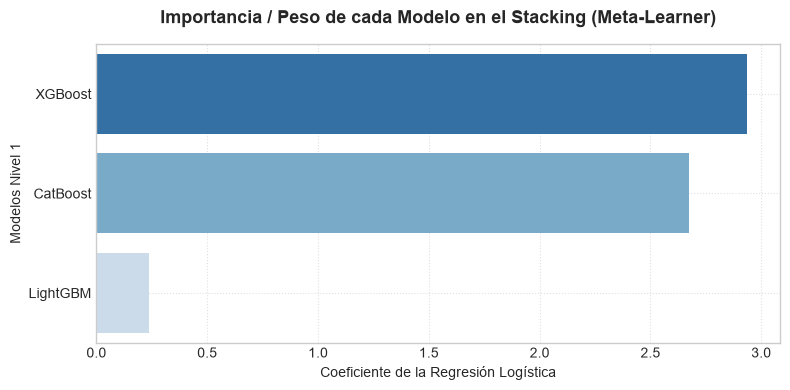


🎢 COMPARACIÓN: Stacking vs Modelos Individuales
----------------------------------------------------------------------------------------------------
Random Forest:        0.8651
XGBoost (optimizado): 0.8679
LightGBM:             0.8562
CatBoost:             0.8642
Stacking (XGB+LGB):   0.8672⭐
💪 Iniciando arquitectura de Blending...


In [16]:
# 1. Empezamos identificando con que modelos alimentaremos el Stacking
print("Diseño selecciondo para nuestro Asamblador:")
print("Modelo XGBoost - LightGBM - CatBoost")
print("-"*100)

# 1.1 NIVEL 1 - Definiendo Learners e imprimiendo que esten correctamentes cargados
base_learners = [
    ('xgboost', xgb.XGBClassifier(
        **xgb_grid.best_params_,  # Usar los mejores parámetros de Grid Search
        random_state=42,
        eval_metric='logloss'
    )),
    ('lightgbm', lgb.LGBMClassifier(
        n_estimators=200,
        num_leaves=31,
        max_depth=5,
        learning_rate=0.1,
        random_state=42,
        verbose=-1
    )),
    ('catboost',CatBoostClassifier(
    iterations=200,
    depth=6,
    learning_rate=0.1,
    l2_leaf_reg=3,         # Regularización L2
    random_state=42,
    verbose=False          # Silencioso
    ))
]

print("¡Modelos Base (Nivel 1)!:")
for name, _ in base_learners:
    print(f"  - {name}")

# 2. NIVEL 2 - Meta Learner (Regresión Logística regularizada)
meta_learner = LogisticRegression(
    C=1.0,
    max_iter=1000,
    random_state=42)

print("Nivel 2 completado con exito")

# 3. Creación Stacking Classifier
stacking_model = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_learner,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    stack_method='predict_proba',
    n_jobs=-1
)

# 4. Imprimiendo tiempo de entrenamiento del modelo

start_time_stk = time.time()
stacking_model.fit(x_train_scaled, y_train)
end_time_stk = time.time()

print("Entrenamiento puede durar algunos minutos.")
print(f"Ensamble Stacking entrenado en {(end_time_stk - start_time_stk)/60:.2f} minutos")
print("-"*100)

# 5. Predicciones de nuestro modelo de ensamble
y_pred_stack = stacking_model.predict(x_test_scaled)
y_pred_proba_stack = stacking_model.predict_proba(x_test_scaled)[:, 1]

# 6. Metricas de Evaluación
accuracy_stk = accuracy_score(y_test, y_pred_stack)
precision_stk = precision_score(y_test, y_pred_stack, pos_label=1)
recall_stk = recall_score(y_test, y_pred_stack, pos_label=1)
f1_stk = f1_score(y_test, y_pred_stack, pos_label=1)

# 6.1 Imprimimos metricas
print("📌 MÉTRICAS DE EVALUACIÓN STACKING CLASSIFIER")
print(classification_report(y_test, y_pred_stack, target_names=['No Churn', 'Churn'], digits=4))
print(f"Accuracy Score: {accuracy_stk:.4f}      | {accuracy_stk*100:.2f}% ")
print(f"Precision Score: {precision_stk:.4f}      | {precision_stk*100:.2f}% ")
print(f"Recall Score: {recall_stk:.4f}      | {recall_stk*100:.2f}% ")
print(f"F1-Score: {f1_stk:.4f}      | {f1_stk*100:.2f}% ")

# 6.2 Curva ROC - AUC
fpr_stk, tpr_stk, thresholds_stk = roc_curve(y_test, y_pred_proba_stack)
roc_auc_stk = auc(fpr_stk, tpr_stk)

print(f"ROC - AUC Score: {roc_auc_stk:.4f}      | {roc_auc_stk*100:.2f}% \n")
print("-"*100)

# 7. Graficamos Matriz de Confusión
stk_mc = confusion_matrix(y_test, y_pred_stack)

# 7.1 Hacemos toda la configuración de valores dentro de los cuadros:
labels_stk = [f'{val_6}\n({pctj_6:.1f}%)' for val_6, pctj_6 in zip 
                    (stk_mc.flatten(), stk_mc.flatten() / stk_mc.sum() * 100)]
labels_stk = np.array(labels_stk).reshape(2, 2)

# 7.2 Graficamos
plt.figure(figsize=(7, 5))
sns.heatmap(
    stk_mc,
    annot= labels_stk,
    fmt= '',
    cmap= 'Blues',
    xticklabels=['Permaneció (0)', 'Churn (1)'],
    yticklabels=['Permaneció (0)', 'Churn (1)'],
    annot_kws={'size':12},
)

plt.title('Matriz de Confusión - MODELO DE ENSAMBLE STACKING', fontsize=14, pad=15)
plt.xlabel('Predicción del Modelo', fontsize=12)
plt.ylabel('Valor Real (Realidad)', fontsize=12)
plt.tight_layout()
plt.show()

# 7.3 Afinamos detalles con respecto a como interpretar la matriz de confusión:
tn_stk, fp_stk, fn_stk, tp_stk = stk_mc.ravel()

print("🚨 DESGLOSE DE LA MATRIZ DE CONFUSIÓN - STACKING:")
print("-" * 100)
print(f"❗❗ Falsos Negativos   (FN): {fn_stk:4d} (Fugas no detectadas - ERROR GRAVE)")
print(f"⭕ Falsos Positivos     (FP): {fp_stk:4d} (Falsas alarmas de churn)")
print(f"✅ Verdaderos Negativos (TN): {tn_stk:4d} (Clientes retenidos predichos correctamente)")
print(f"✅ Verdaderos Positivos (TP): {tp_stk:4d} (Clientes en churn detectados a tiempo)")
print("-"*100)

# 8. Coeficientes de peso y ponderando su valor a %
coefficients = stacking_model.final_estimator_.coef_[0]
model_names = ['XGBoost', 'LightGBM', 'CatBoost']

# Ponderando los valores a porcentaje
weights_pct = (np.exp(coefficients) / np.sum(np.exp(coefficients))) * 100

# Creando el DataFrame donde tendremos los coeficientes
stacking_weights_df = pd.DataFrame({
    'Modelo_Base': model_names,
    'Peso_MetaLearner': coefficients
}).sort_values('Peso_MetaLearner', ascending=False)

print("⚖️ PESOS Y CONFIANZA ASIGNADOS POR EL META-LEARNER:")
print(stacking_weights_df.to_string(index=False))

# 8.1 Graficamos los Coeficientes de peso
plt.figure(figsize=(8, 4))
sns.barplot(data=stacking_weights_df, x='Peso_MetaLearner', y='Modelo_Base', palette='Blues_r')
plt.title('Importancia / Peso de cada Modelo en el Stacking (Meta-Learner)', fontsize=13, pad=15)
plt.xlabel('Coeficiente de la Regresión Logística')
plt.ylabel('Modelos Nivel 1')
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

# 9. Comparación de ROC - AUC entre los modelos que hemos predecido
print("\n🎢 COMPARACIÓN: Stacking vs Modelos Individuales")
print("-" * 100)
print(f"Random Forest:        {roc_auc_random_f:.4f}")
print(f"XGBoost (optimizado): {roc_auc_xgb_best:.4f}")
print(f"LightGBM:             {roc_auc_lgb:.4f}")
print(f"CatBoost:             {roc_auc_cat:.4f}")
print(f"Stacking (XGB+LGB):   {roc_auc_stk:.4f}⭐")
# Creando Blending
print("💪 Iniciando arquitectura de Blending...")

### 💻 7. Modelo de Ensamble Blending

***Contexto Breve:***
Blending, o conocido como "mezcla", es una técnica avanzada de Ensemble Learning (aprendizaje en conjunto), en el que se combinan las predicciones de múltiples modelos de Machine Learning diferentes para crear una predicción final mucho más sólida, precisa y estable.

**Función:**
- Usualmente se divide el conjunto de entrenamiento original en dos: Entrenamiento Base (70%) y un Holdout/Blending Set (30%).
- Los modelos base se entrenan solo en el 70%.
- Se predice probabilidades sobre el Holdout/Blending Set (30%) y sobre ellas ajustamos una Regresión Logística (o encontramos la Ponderación Óptima / Pesos) para obtener la combinación perfecta.

### 📊 1. Desempeño General
- Accuracy (86.50%): mantiene una capacidad global de clasificación sólida sobre la muestra de prueba.
- ROC - AUC (86.08%): excelente capacidad para ordenar y separar las probabilidades entre clientes en churn y clientes estables.
- Precision de Churn (75.85%): porcentaje de clientes catalogados en riesgo por el ensamble que realmente si abandonan el servicio
- Recall de Churn (49.39%): porcentaje total de los clientes que efectivamente hicieron churn detectados a tiempo.

### 🚨 2. Diagnóstico de la Matriz de Confusión
- Verdaderos Negativos (TN): 1,529 clientes (76.4%) retenidos predichos correctamente.
- Verdaderos Positivos (TP): 201 clientes (10.1%) en churn identificados a tiempo.
- Falsos Positivos (FP): 64 clientes (3.2%) catalogados erróneamente como churn (falsas alarmas).
- Falsos Negativos (FN): 206 clientes (10.3%) en churn que no fueron detectados por el modelo.

### ⚖️ 3. Distribución de Pesos en el Meta-Learner
En la arquitectura Blending, el Meta-Learner ponderó los 3 modelos base de la siguiente manera:

- XGBoost (54%): asume el rol dominante del ensamble en la toma de decisiones.
- CatBoost (32%): aporta estabilidad y soporte complementario.
- LightGBM (14%): actúa como un modelo de ajuste fino secundario.

📊 Registros para Entrenar Modelos Base: 5600
📊 Registros en Holdout para el Meta-Learner: 2400
📊 Registros en Test Set Final: 2000

¡Entrenando modelos base en Train Base (70%)...
Generando probabilidades sobre Holdout Set para el Meta-Learner...
✅ Ensamble Blending completado en 1.04 segundos

----------------------------------------------------------------------------------------------------
📌 MÉTRICAS DE EVALUACIÓN - BLENDING CLASSIFIER
              precision    recall  f1-score   support

    No Churn     0.8813    0.9598    0.9189      1593
       Churn     0.7585    0.4939    0.5982       407

    accuracy                         0.8650      2000
   macro avg     0.8199    0.7268    0.7585      2000
weighted avg     0.8563    0.8650    0.8536      2000

Accuracy Score:  0.8650      | 86.50% 
Precision Score: 0.7585      | 75.85% 
Recall Score:    0.4939      | 49.39% 
F1-Score:        0.5982      | 59.82% 
ROC - AUC Score: 0.8608      | 86.08%

----------------------------------

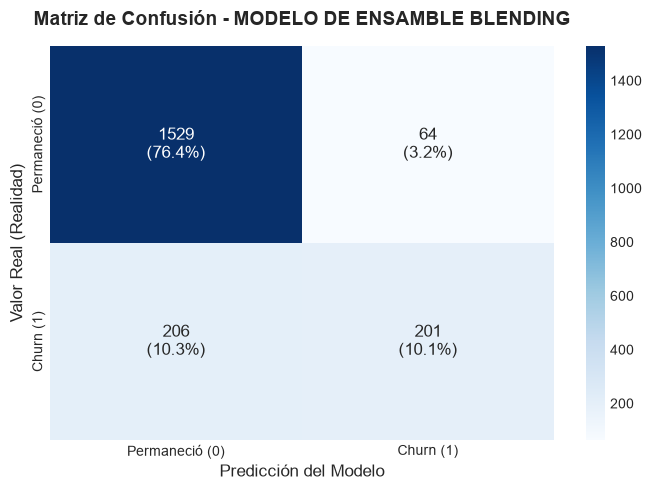


⚖️ PONDERACIÓN Y PESOS DEL META-LEARNER EN BLENDING:
Modelo_Base  Coeficiente_Raw  Peso_Relativo_(%)
    XGBoost         2.592838          53.828959
   CatBoost         2.074759          32.063978
   LightGBM         1.253702          14.107063


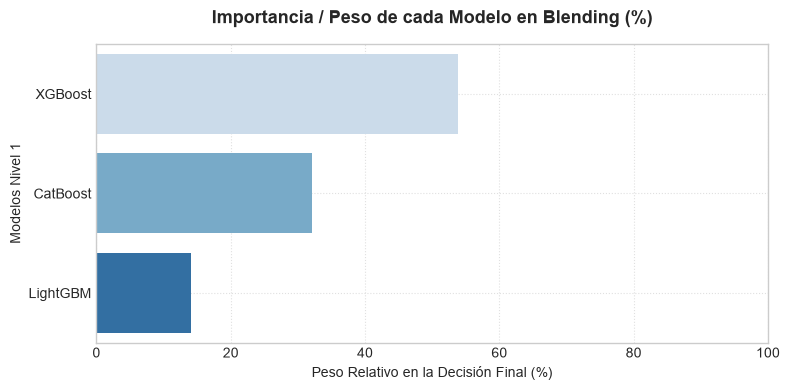

In [17]:
# 1. Creamos la división de las variables 70/30 e imprimimos
x_train_base, x_blend, y_train_base, y_blend = train_test_split(
    x_train_scaled, y_train, test_size=0.30, random_state=42, stratify=y_train
)

print(f"📊 Registros para Entrenar Modelos Base: {x_train_base.shape[0]}")
print(f"📊 Registros en Holdout para el Meta-Learner: {x_blend.shape[0]}")
print(f"📊 Registros en Test Set Final: {x_test_scaled.shape[0]}\n")

# 2. Definimos parametros y entrenamos los modelos con x_train_base
xgb_blend_model = xgb.XGBClassifier(
    **xgb_grid.best_params_, 
    random_state=42, 
    eval_metric='logloss'
)
lgb_blend_model = lgb.LGBMClassifier(
    n_estimators=200, num_leaves=31, max_depth=5, 
    learning_rate=0.1, random_state=42, verbose=-1
)
cat_blend_model = CatBoostClassifier(
    iterations=200, depth=6, learning_rate=0.1, 
    l2_leaf_reg=3, random_state=42, verbose=False
)

start_time_blend = time.time()
print("¡Entrenando modelos base en Train Base (70%)...")
xgb_blend_model.fit(x_train_base, y_train_base)
lgb_blend_model.fit(x_train_base, y_train_base)
cat_blend_model.fit(x_train_base, y_train_base)

# 3. Generamos matriz de metacaracteristicas sobre el hold-out set
print("Generando probabilidades sobre Holdout Set para el Meta-Learner...")
blend_p_xgb = xgb_blend_model.predict_proba(x_blend)[:, 1]
blend_p_lgb = lgb_blend_model.predict_proba(x_blend)[:, 1]
blend_p_cat = cat_blend_model.predict_proba(x_blend)[:, 1]

# 3.1 Unimos las 3 columnas de probabilidades
X_blend_meta = np.column_stack((blend_p_xgb, blend_p_lgb, blend_p_cat))

# 4. Entrenamos el meta-learn
meta_learner_blend = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
meta_learner_blend.fit(X_blend_meta, y_blend)

end_time_blend = time.time()
print(f"✅ Ensamble Blending completado en {(end_time_blend - start_time_blend):.2f} segundos\n")
print("-" * 100)

# 5. Obtenemos predicciones de cada modelo sobre tu x_test_scaled original
test_p_xgb = xgb_blend_model.predict_proba(x_test_scaled)[:, 1]
test_p_lgb = lgb_blend_model.predict_proba(x_test_scaled)[:, 1]
test_p_cat = cat_blend_model.predict_proba(x_test_scaled)[:, 1]

X_test_meta = np.column_stack((test_p_xgb, test_p_lgb, test_p_cat))

# 5.1 Predicción final del Meta-Learner
y_pred_proba_blend = meta_learner_blend.predict_proba(X_test_meta)[:, 1]
y_pred_blend = meta_learner_blend.predict(X_test_meta)

# 6. MÉTRICAS DE EVALUACIÓN
accuracy_bld = accuracy_score(y_test, y_pred_blend)
precision_bld = precision_score(y_test, y_pred_blend, pos_label=1)
recall_bld = recall_score(y_test, y_pred_blend, pos_label=1)
f1_bld = f1_score(y_test, y_pred_blend, pos_label=1)

fpr_bld, tpr_bld, _ = roc_curve(y_test, y_pred_proba_blend)
roc_auc_bld = auc(fpr_bld, tpr_bld)

print("📌 MÉTRICAS DE EVALUACIÓN - BLENDING CLASSIFIER")
print(classification_report(y_test, y_pred_blend, target_names=['No Churn', 'Churn'], digits=4))
print(f"Accuracy Score:  {accuracy_bld:.4f}      | {accuracy_bld*100:.2f}% ")
print(f"Precision Score: {precision_bld:.4f}      | {precision_bld*100:.2f}% ")
print(f"Recall Score:    {recall_bld:.4f}      | {recall_bld*100:.2f}% ")
print(f"F1-Score:        {f1_bld:.4f}      | {f1_bld*100:.2f}% ")
print(f"ROC - AUC Score: {roc_auc_bld:.4f}      | {roc_auc_bld*100:.2f}%\n")
print("-" * 100)

# 7. MATRIZ DE CONFUSIÓN
bld_mc = confusion_matrix(y_test, y_pred_blend)
labels_bld = [f'{val_6}\n({pct_6:.1f}%)' for val_6, pct_6 in zip(bld_mc.flatten(), bld_mc.flatten() / bld_mc.sum() * 100)]
labels_bld = np.array(labels_bld).reshape(2, 2)

plt.figure(figsize=(7, 5))
sns.heatmap(bld_mc, annot=labels_bld, fmt='', cmap='Blues',
            xticklabels=['Permaneció (0)', 'Churn (1)'],
            yticklabels=['Permaneció (0)', 'Churn (1)'],
            annot_kws={'size': 12})
plt.title('Matriz de Confusión - MODELO DE ENSAMBLE BLENDING', fontsize=14, pad=15)
plt.xlabel('Predicción del Modelo', fontsize=12)
plt.ylabel('Valor Real (Realidad)', fontsize=12)
plt.tight_layout()
plt.show()

# 8. PONDERACIÓN ÓPTIMA Y IMPORTANCIA DE MODELOS EN BLENDING
coefficients_bld = meta_learner_blend.coef_[0]
weights_pct_bld = (np.exp(coefficients_bld) / np.sum(np.exp(coefficients_bld))) * 100

blending_weights_df = pd.DataFrame({
    'Modelo_Base': ['XGBoost', 'LightGBM', 'CatBoost'],
    'Coeficiente_Raw': coefficients_bld,
    'Peso_Relativo_(%)': weights_pct_bld
}).sort_values('Peso_Relativo_(%)', ascending=False)

print("\n⚖️ PONDERACIÓN Y PESOS DEL META-LEARNER EN BLENDING:")
print(blending_weights_df.to_string(index=False))

plt.figure(figsize=(8, 4))
sns.barplot(data=blending_weights_df, x='Peso_Relativo_(%)', y='Modelo_Base', palette='Blues')
plt.title('Importancia / Peso de cada Modelo en Blending (%)', fontsize=13, pad=15)
plt.xlabel('Peso Relativo en la Decisión Final (%)')
plt.ylabel('Modelos Nivel 1')
plt.xlim(0, 100)
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

### 7.1 ⚔️ Comparativa Directa: Stacking vs. Blending

- | Métrica - Aspecto | Stacking Classifier | Blending Classifier |

- | **Accuracy**          | ⭐86.95%  | 86.50% |
- | **ROC - AUC**         | ⭐86.72%  | 86.08% |
- | **Precision (Churn)** | ⭐78.97%  | 75.85% |
- | **Recall (Churn)**    | 48.89%    | ⭐49.39% |
- | **F1-Score**          | ⭐60.39%  | 59.82% |

### 💡 Conclusión y Comparación Técnica
**Eficiencia de los Datos vs. Muestreo:**
- Stacking supera a Blending en casi todas las métricas globales (Accuracy, ROC-AUC, Precision y F1-Score). Esto ocurre porque Stacking utilizó 5-Fold Cross Validation sobre el 100% del dataset de entrenamiento para construir las meta-características, aprovechando mejor toda la información disponible.
- Blending, al reservar un 30% fijo del set de entrenamiento (Holdout) exclusivamente para el Meta-Learner, redujo la cantidad de datos que los modelos base pudieron ver durante su fase de entrenamiento inicial.

**Costo de Errores de Negocio:**
- Stacking comete menos falsas alarmas (53 FP vs. 64 FP en Blending), lo que optimiza el presupuesto en campañas de retención.
- Blending logra capturar 2 clientes adicionales en fuga (206 FN vs. 208 FN en Stacking), otorgándole un Recall ligeramente superior (49.39 vs. 48.89%).

### ❗❗ Recomendación Final: 
**El modelo Stacking Classifier se consagra como la arquitectura de ensamble óptima para este proyecto gracias a la técnica de validación cruzada, ofreciendo el equilibrio ideal entre precisión comercial y robustez general.**

In [18]:
# 9. Creando Tabla para Markdown con las comparativas entre Stacking - Blending
tabla_markdown = f"""
| Métrica / Aspecto | Stacking Classifier | Blending Classifier |
|
| **Accuracy**          | ⭐{accuracy_stk*100:.2f}%  | {accuracy_bld*100:.2f}% |
| **ROC - AUC**         | ⭐{roc_auc_stk*100:.2f}%  | {roc_auc_bld*100:.2f}% |
| **Precision (Churn)** | ⭐{precision_stk*100:.2f}%  | {precision_bld*100:.2f}% |
| **Recall (Churn)**    | {recall_stk*100:.2f}%    | ⭐{recall_bld*100:.2f}% |
| **F1-Score**          | ⭐{f1_stk*100:.2f}%  | {f1_bld*100:.2f}% |
"""

# 2. Imprimimos el resultado listo para copiar
print(tabla_markdown)


| Métrica / Aspecto | Stacking Classifier | Blending Classifier |
|
| **Accuracy**          | ⭐86.95%  | 86.50% |
| **ROC - AUC**         | ⭐86.72%  | 86.08% |
| **Precision (Churn)** | ⭐78.97%  | 75.85% |
| **Recall (Churn)**    | 48.89%    | ⭐49.39% |
| **F1-Score**          | ⭐60.39%  | 59.82% |



### 💻 8. Estrategias de Validación Cruzada 🔀

***Concepto Breve:***
Se utilizan principalmente para garantizar que el modelo o los modelos entrenados funcione igual de bien en el mundo real con datos nuevos que nunca antes ha visto.

- K-Fold (Básico): el objetivo principal es evitar evaluar un modelo con un solo trozo de datos, dividiendo y rotando tu base de datos múltiples veces para que todo tu conjunto de datos sea probado al menos una vez. Desventaja:  con clases desbalanceadas, puede crear folds con proporciones muy diferentes.
- StratifiedKFold: es la técnica ideal para datasets con clases desbalanceadas (80-20). Mantiene la misma proporción de la variable objetivo (0s y 1s) en cada uno de los K pliegues (folds), evitando que un fold quede sin ejemplos de fuga.
- GroupKFold: se usa cuando las observaciones pertenecen a grupos (por ejemplo, múltiples registros de la misma empresa o familia) para evitar que datos del mismo grupo estén en entrenamiento y prueba al mismo tiempo (data leakage).
- StratifiedGroupKFold: combina el manejo de grupos con la estratificación de la variable objetivo.
- TimeSeriesSplit: Diseñada para datos con dependencia temporal (series de tiempo), respetando el orden cronológico. 
**En nuestro dataset no aplica dado que no cuenta con columnas con datos temporales continuos (como fecha).**

***Métricas***
- PR-AUC (Precision-Recall AUC): se enfoca exclusivamente en el desempeño sobre la clase positiva (Churn), sin dejarse distorsionar por la abundancia de la clase negativa.
- ROC-AUC: Mide la capacidad global del modelo para ordenar y separar ambas clases a lo largo de distintos umbrales de decisión.
- Business Metric Personalizada (Costo/Beneficio): Asigna un valor monetario a los aciertos y errores. Por ejemplo, en nuestro Dataset: 

-> Costo de retención (FP): Oferta de $20 para retener a alguien que no se iba a ir.
-> Costo de fuga no detectada (FN): Pérdida del cliente ($100).
-> Beneficio de retener a tiempo (TP): Cliente recuperado ($80 netos).

### Importante! Para este modelo compararemos 2 estrategias de validación cruzada.

### 📌 Resumen Ejecutivo: Comparativa de Validación Cruzada
Al evaluar el modelo mediante un esquema de 5 particiones (5-Folds), se comparó el comportamiento entre Standard K-Fold y Stratified K-Fold:

1. **Standard K-Fold:** Divide los datos en 5 partes de manera completamente aleatoria sin considerar la distribución de las clases.
2. **Stratified K-Fold:** Divide los datos garantizando que cada uno de los 5 bloques contenga exactamente la misma proporción entre clientes en *Churn* (clase minoritaria) y *No Churn*.

#### 📊 Aspectos Clave del Rendimiento:
Mejora en la Detección de Churn: Stratified K-Fold supera a Standard K-Fold en todas las métricas directas de clasificación de la clase minoritaria:
- Accuracy: Sube de 86.24% a 86.42%.
- Precision (Churn): Aumenta de 75.28% a 76.13%, reduciendo las falsas alarmas.
- Recall (Churn): Incrementa de 48.34% a 48.59%, capturando más casos reales de churn.
- F1-Score: Pasa de 58.87% a 59.31%, demostrando un mejor equilibrio general.

**Estabilidad y Varianza:** Aunque las métricas globales como ROC - AUC (86.76% vs. 86.54%) y PR - AUC (70.73% vs. 70.28%) se mantienen muy similares entre ambas estrategias, la desviación estándar en Stratified K-Fold refleja la variabilidad real entre bloques al forzar que cada uno mantenga la proporción exacta del 20% de la clase Churn.

In [19]:
# 1. Realizaremos uso de 2 estrategias para comparar rendimientos.
print("🔄 COMPARANDO ESTRATEGIAS DE VALIDACIÓN CRUZADA")
print("-" * 100)

# 2.1 Creamos estrategia de comparación
cv_kfold = KFold(n_splits=5, shuffle=True, random_state=42)
cv_stratified = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2.2 Creamos la lista de métricas para el cross-validation
scoring_metrics = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc',
    'pr_auc': 'average_precision'
}

# Tomando tiempo de ejecución
cv_start_time = time.time()

# 2.3 Uso de función auxiliar para ejecutar cross_validate y resumir
def evaluar_cv(estrategia, nombre_estrategia):
    results = cross_validate(
        estimator=stacking_model,  
        X=x_train_scaled, 
        y=y_train, 
        cv=estrategia, 
        scoring=scoring_metrics,
        n_jobs=-1
    )
    resumen = {
        'Estrategia': nombre_estrategia,
        'Accuracy': f"{np.mean(results['test_accuracy'])*100:.2f}% (±{np.std(results['test_accuracy'])*100:.2f}%)",
        'Precision (Churn)': f"{np.mean(results['test_precision'])*100:.2f}% (±{np.std(results['test_precision'])*100:.2f}%)",
        'Recall (Churn)': f"{np.mean(results['test_recall'])*100:.2f}% (±{np.std(results['test_recall'])*100:.2f}%)",
        'F1-Score': f"{np.mean(results['test_f1'])*100:.2f}% (±{np.std(results['test_f1'])*100:.2f}%)",
        'ROC - AUC': f"{np.mean(results['test_roc_auc'])*100:.2f}% (±{np.std(results['test_roc_auc'])*100:.2f}%)",
        'PR - AUC': f"{np.mean(results['test_pr_auc'])*100:.2f}% (±{np.std(results['test_pr_auc'])*100:.2f}%)"
    }
    return resumen, results

# 3. Corremos ambas validaciones
res_kfold, raw_kfold = evaluar_cv(cv_kfold, 'Standard K-Fold (5-Folds)')
res_stratified, raw_stratified = evaluar_cv(cv_stratified, 'Stratified K-Fold (5-Folds)')

cv_end_time = time.time()
print(f"Tiempo de Ejecución de nuestras Validaciones Cruzadas: {(cv_end_time - cv_start_time)/60:.2f} minutos")

# 4. Creamos la tabla comparativa
df_comparativa_cv = pd.DataFrame([res_kfold, res_stratified])

# 5. Transponemos para que las métricas queden en las filas
df_comparativa_cv_t = df_comparativa_cv.set_index('Estrategia').T.reset_index()
df_comparativa_cv_t.columns = ['Métrica / Aspecto', 'Standard K-Fold (5-Folds)', 'Stratified K-Fold (5-Folds)']

print("\n📌 COMPARACIÓN DE ESTRATEGIAS DE VALIDACIÓN CRUZADA:")
print(df_comparativa_cv_t.to_string(index=False))

# 6. Análisis de nuestras estrategias de validación
print("\n" + "-" * 100)
print("ESTRATEGIAS DE VALIDACIÓN CRUZADA - Análisis")
print("✴️ StratifiedKFold es la mejor opción para nuestro dataset porque:")
print("   ✅ Mantiene proporciones de clases (20% Churn en cada fold)")
print("   ✅ Reduce varianza en las estimaciones")
print("   ✅ Evaluación más confiable")
print("-" * 100)
print("K-Fold Standard puede tener mayor varianza por desbalance.\n")

🔄 COMPARANDO ESTRATEGIAS DE VALIDACIÓN CRUZADA
----------------------------------------------------------------------------------------------------
Tiempo de Ejecución de nuestras Validaciones Cruzadas: 0.34 minutos

📌 COMPARACIÓN DE ESTRATEGIAS DE VALIDACIÓN CRUZADA:
Métrica / Aspecto Standard K-Fold (5-Folds) Stratified K-Fold (5-Folds)
         Accuracy           86.24% (±0.62%)             86.42% (±0.74%)
Precision (Churn)           75.28% (±1.20%)             76.13% (±2.52%)
   Recall (Churn)           48.34% (±0.72%)             48.59% (±2.33%)
         F1-Score           58.87% (±0.34%)             59.31% (±2.44%)
        ROC - AUC           86.76% (±0.76%)             86.54% (±1.00%)
         PR - AUC           70.73% (±0.48%)             70.28% (±2.29%)

----------------------------------------------------------------------------------------------------
ESTRATEGIAS DE VALIDACIÓN CRUZADA - Análisis
✴️ StratifiedKFold es la mejor opción para nuestro dataset porque:
   ✅ Mantiene

### 8.1 ⚔️ Comparativa Entre Estrategias: Standard K-Fold - Stratified K-Fold

### 📌 Resumen de los Boxplots Comparativos de CV

**📊 Hallazgos por Métrica:**
- ROC-AUC (Discriminación de Clases): ambas estrategias muestran mediana y comportamiento general equivalentes alrededor de 0.865–0.867.K-Fold (Normal) muestra una ligera variabilidad uniforme, mientras que StratifiedKFold presenta un límite inferior un poco más extendido hacia 0.848 en uno de los folds, pero manteniendo una mediana sólida.

- F1-Score (Equilibrio Precision / Recall):
K-Fold Standard: Muestra una caja sumamente estrecha con valores casi constantes en torno a 0.589, pero con outliers (puntos aislados), lo que indica que la distribución aleatoria no balanceada puede generar estimaciones atípicas.
StratifiedKFold: Exhibe un rango más amplio (0.563$ a 0.622) con mediana superior (0.597). Refleja la variabilidad real entre folds cuando cada uno contiene la proporción exacta del 20% de Churn, alcanzando picos más altos de F1-Score.

- Accuracy (Exactitud Global):
StratifiedKFold alcanza una mediana más alta (0.867) y un tope superior superior frente a K-Fold Normal (0.873).
K-Fold Normal presenta un outlier en el extremo inferior (0.851), lo que evidencia que un fold con baja representación de la clase minoritaria degrada el rendimiento del modelo.

### 💡 Conclusión:
Los boxplots confirman que StratifiedKFold es la mejor elección: evita los datos atípicos (outliers) causados por sesgos de muestreo en folds individuales y alcanza picos superiores tanto en F1-Score como en Accuracy, garantizando una evaluación mucho más representativa y robusta del modelo.

📊 DISTRIBUCIÓN DE MUESTRAS Y CHURN POR FOLD (StratifiedKFold):
----------------------------------------------------------------------------------------------------
Fold 0:
   Train: 6400 muestras, Churn: 20.4%
   Val:   1600 muestras, Churn: 20.4%
Fold 1:
   Train: 6400 muestras, Churn: 20.4%
   Val:   1600 muestras, Churn: 20.4%
Fold 2:
   Train: 6400 muestras, Churn: 20.4%
   Val:   1600 muestras, Churn: 20.4%
Fold 3:
   Train: 6400 muestras, Churn: 20.4%
   Val:   1600 muestras, Churn: 20.4%
Fold 4:
   Train: 6400 muestras, Churn: 20.4%
   Val:   1600 muestras, Churn: 20.4%

✅ Todas las proporciones son similares (estratificación correcta)


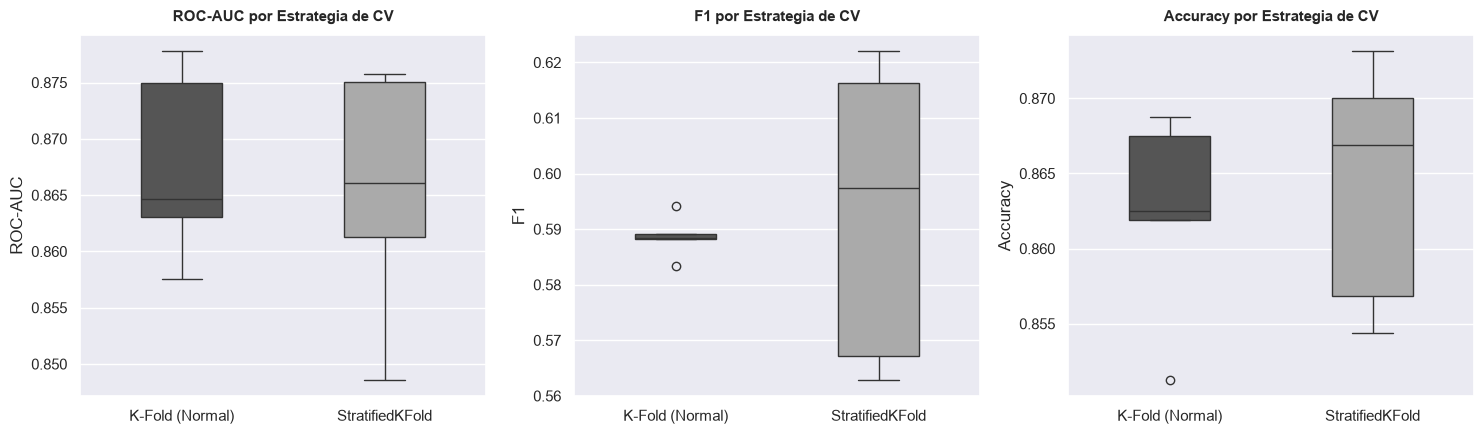

In [20]:
# 7. Imprimimos las distribuciones de Churn por Fold
print("📊 DISTRIBUCIÓN DE MUESTRAS Y CHURN POR FOLD (StratifiedKFold):")
print("-" * 100)

for fold_idx, (train_idx, val_idx) in enumerate(cv_stratified.split(x_train_scaled, y_train)):

    # Calculamos distribución de Churn de forma segura:
    y_train_fold = y_train[train_idx]
    y_val_fold = y_train[val_idx]

    # Calculamos porcentaje:
    train_churn_pct = (y_train_fold == 1).mean() * 100
    val_churn_pct = (y_val_fold == 1).mean() * 100

    print(f"Fold {fold_idx}:")
    print(f"   Train: {len(train_idx):4d} muestras, Churn: {train_churn_pct:.1f}%")
    print(f"   Val:   {len(val_idx):4d} muestras, Churn: {val_churn_pct:.1f}%")

print("\n✅ Todas las proporciones son similares (estratificación correcta)")

# 8. Graficamos la comparación con Boxplots (Estabilidad por Métricas)
df_box = pd.DataFrame([
    {'Estrategia': est_name, 'Métrica': metrica, 'Score': score}
    for est_name, raw_res in [('K-Fold (Normal)', raw_kfold), ('StratifiedKFold', raw_stratified)]
    for metrica, key in [('ROC-AUC', 'test_roc_auc'), ('F1', 'test_f1'), ('Accuracy', 'test_accuracy')]
    for score in raw_res[key]
])

sns.set_theme(style="darkgrid")
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

metricas = ['ROC-AUC', 'F1', 'Accuracy']
for i, metrica in enumerate(metricas):
    sns.boxplot(
        data=df_box[df_box['Métrica'] == metrica], 
        x='Estrategia', 
        y='Score', 
        ax=axes[i], 
        palette='grey', 
        width=0.4
    )
    axes[i].set_title(f'{metrica} por Estrategia de CV', fontsize=11, fontweight='bold', pad=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel(metrica)

plt.tight_layout()
plt.show()

### 9 ⚔️ COMPARACIÓN EXHAUSTIVA DE METRICAS DE TODOS LOS MODELOS

***Breve concepto:***
Vamos a recapitular todas las metricas realizadas por nuestros modelos, incluyendo nuestros dos (dos) modelos de ensamble (Stacking - Blending). Esto se realizará con todas las **metricas de evaluación**.
No Obstante, recordemos que **Accuracy** es engañosa con datos desbalanceados.

⚔️ COMPARACIÓN DE METRICAS DE TODOS LOS MODELOS


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished



📌 TABLA COMPARATIVA DE MÉTRICAS EVALUADORAS:
              Modelo  Accuracy  Precision   Recall  F1-Score  ROC-AUC   PR-AUC
 Regresión Logistica    0.8080   0.589147 0.186732  0.283582 0.774778 0.478974
       Random Forest    0.8675   0.828704 0.439803  0.574639 0.865073 0.704978
  XGBoost (Baseline)    0.8670   0.785425 0.476658  0.593272 0.866902 0.712899
XGBoost (Optimizado)    0.8695   0.789683 0.488943  0.603945 0.867922 0.720564
            LightGBM    0.8640   0.750929 0.496314  0.597633 0.856204 0.702020
            CatBoost    0.8685   0.779070 0.493857  0.604511 0.864189 0.721173
            Stacking    0.8695   0.789683 0.488943  0.603945 0.867202 0.721196
            Blending    0.8650   0.758491 0.493857  0.598214 0.860758 0.713864

----------------------------------------------------------------------------------------------------

🏆 MEJOR MODELO POR MÉTRICA
Accuracy     : XGBoost (Optimizado)   (⭐0.8695)
Precision    : Random Forest          (⭐0.8287)
Recall       : Li

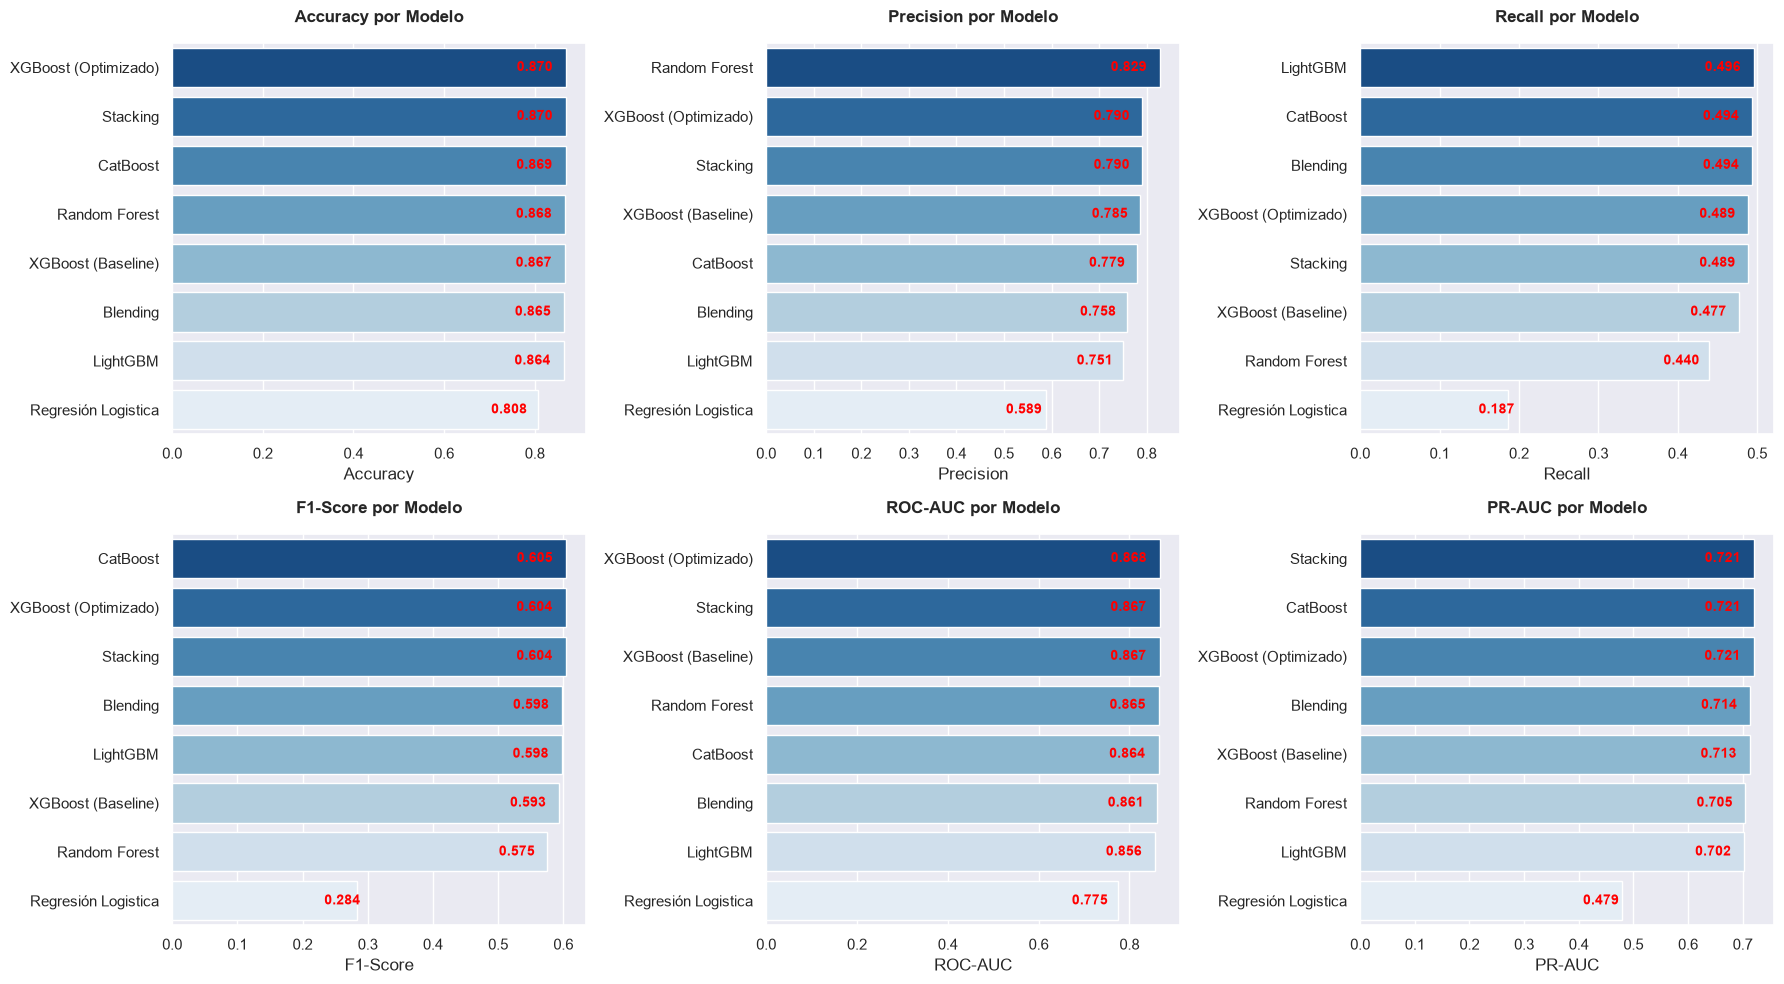

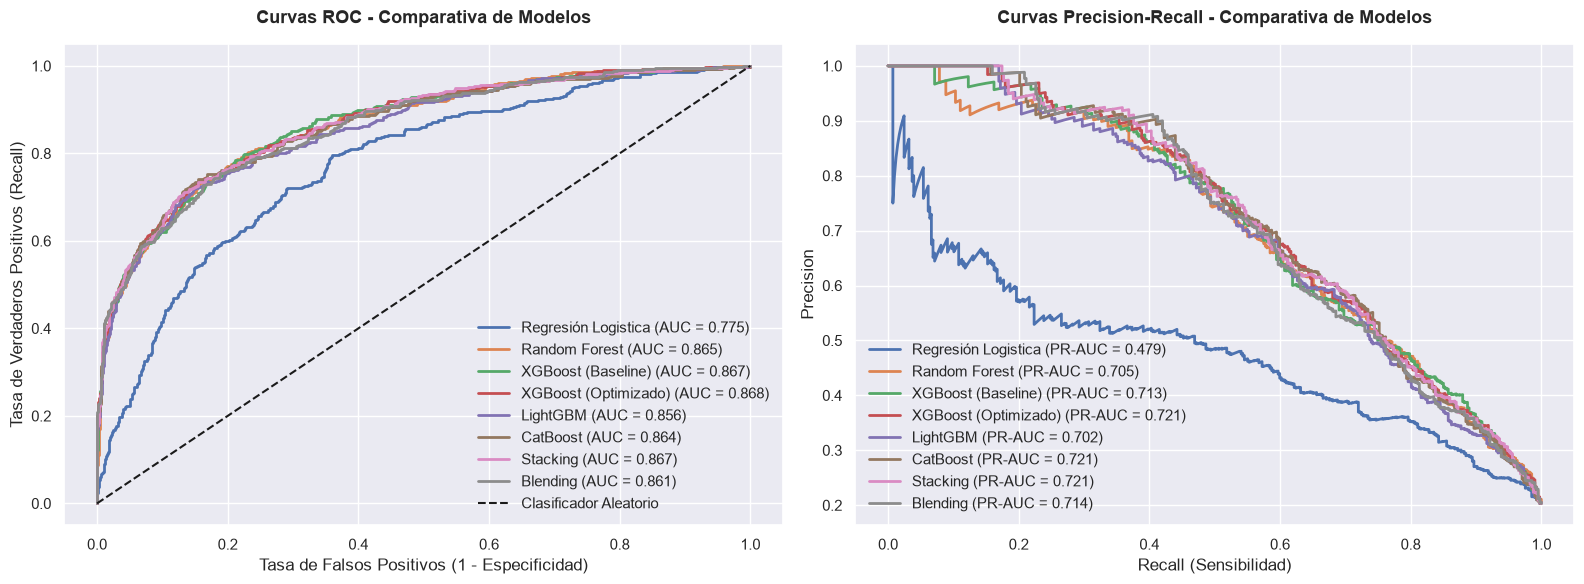

In [21]:
# 1. Recopilar las variables donde tenemos nuestras metricas y prepararlas para imprimirlas / graficarlas
print("⚔️ COMPARACIÓN DE METRICAS DE TODOS LOS MODELOS")

sns.set_theme(style="darkgrid")

# 1.1 Creación de diccionario para las metricas de evalución de cada modelo
modelos_estandar = {
    'Regresión Logistica': modelo_rl,
    'Random Forest': modelo_random_f,
    'XGBoost (Baseline)': xgb_base,
    'XGBoost (Optimizado)': xgb_grid,
    'LightGBM': lgb_model,
    'CatBoost': catboost_model,
    'Stacking': stacking_model
}

# 1.2 Creo una lista vacia pra guardar los resultados
resultados = []

for nombre, model in modelos_estandar.items():
    # Predicciones
    y_pred = model.predict(x_test_scaled)
    y_proba = model.predict_proba(x_test_scaled)[:, 1]
    
    # Métricas
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)
    
    # Matriz de confusión
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    
    resultados.append({
        'Modelo': nombre,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'ROC-AUC': roc_auc,
        'PR-AUC': pr_auc,
        'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp,
        'y_proba': y_proba
    })

# Agregamos las anotaciones especiales paara Blending
p_xgb_test = xgb_blend_model.predict_proba(x_test_scaled)[:, 1]
p_lgb_test = lgb_blend_model.predict_proba(x_test_scaled)[:, 1]
p_cat_test = cat_blend_model.predict_proba(x_test_scaled)[:, 1]

# Unimos todas las predicciones en una columna
X_test_blend_meta = np.column_stack((p_xgb_test, p_lgb_test, p_cat_test))

# Predicciones finales con el meta-learner
y_pred_blend_p = meta_learner_blend.predict(X_test_blend_meta)
y_proba_blend_p = meta_learner_blend.predict_proba(X_test_blend_meta)[:, 1]

tn_b, fp_b, fn_b, tp_b = confusion_matrix(y_test, y_pred_blend_p).ravel()

resultados.append({
    'Modelo': 'Blending',
    'Accuracy': accuracy_score(y_test, y_pred_blend_p),
    'Precision': precision_score(y_test, y_pred_blend_p),
    'Recall': recall_score(y_test, y_pred_blend_p),
    'F1-Score': f1_score(y_test, y_pred_blend_p),
    'ROC-AUC': roc_auc_score(y_test, y_proba_blend_p),
    'PR-AUC': average_precision_score(y_test, y_proba_blend_p),
    'TN': tn_b, 'FP': fp_b, 'FN': fn_b, 'TP': tp_b,
    'y_proba': y_proba_blend_p
})

df_resultados = pd.DataFrame(resultados)

columnas_tabla = ['Modelo', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'PR-AUC']
df_tabla = df_resultados[columnas_tabla].copy()

print("\n📌 TABLA COMPARATIVA DE MÉTRICAS EVALUADORAS:")
print(df_tabla.to_string(index=False))
print("\n" + "-"*100 + "\n")

# 2. Imprimimos las metricas del mejor modelo
print("🏆 MEJOR MODELO POR MÉTRICA")
for col in ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'PR-AUC']:
    idx_max = df_resultados[col].idxmax()
    mejor_modelo = df_resultados.loc[idx_max, 'Modelo']
    val_max = df_resultados.loc[idx_max, col]
    print(f"{col:<12} : {mejor_modelo:<22} (⭐{val_max:.4f})")

# 2.1 Imprimimos el desgloce de valores que nos muestra la matriz de confusión (No se va a graficar en esta parte)
idx_mejor_fn = df_resultados['FN'].idxmin()
row_top = df_resultados.loc[idx_mejor_fn]

print("\n" + "-"*100)
print(f"🎯 MODELO DESTACADO EN DETECCIÓN DE CHURN (Menor Falsos Negativos): {row_top['Modelo']}")
print(f"  ⭕ Falsos Negativos (FN): {row_top['FN']:4d} (Fugas no detectadas - Error Grave)")
print(f"  ⭕ Falsos Positivos (FP): {row_top['FP']:4d} (Falsas alarmas de churn)")
print(f"  ✅ Verdaderos Negativos (TN): {row_top['TN']:4d} (Clientes retenidos detectados)")
print(f"  ✅ Verdaderos Positivos (TP): {row_top['TP']:4d} (Clientes en churn detectados a tiempo)")
print("_"*100 + "\n")

# 3. Realizamos ls graficas de todas las metricas incluyendo los modelos.
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

metricas_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'PR-AUC']

for i, metrica in enumerate(metricas_plot):
    df_sorted = df_resultados.sort_values(by=metrica, ascending=False)
    
    sns.barplot(
        data=df_sorted,
        x=metrica,
        y='Modelo',
        hue='Modelo',
        ax=axes[i],
        palette='Blues_r',
        legend=False
    )
    
    axes[i].set_title(f'{metrica} por Modelo', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(metrica)
    axes[i].set_ylabel('')
    
    for bar in axes[i].patches:
        width = bar.get_width()
        offset = width * 0.08
        axes[i].text(
            width - offset,
            bar.get_y() + bar.get_height() / 2,
            f'{width:.3f}',
            ha='center', va='center', color='red', fontsize=10, fontweight='bold'
        )

plt.tight_layout()
plt.show()

# 4. Graficas de nuestras curvas ROC - AUC
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Curva ROC ---
for _, row in df_resultados.iterrows():
    fpr_mm, tpr_mm, _ = roc_curve(y_test, row['y_proba'])
    axes[0].plot(fpr_mm, tpr_mm, label=f"{row['Modelo']} (AUC = {row['ROC-AUC']:.3f})", linewidth=2)

axes[0].plot([0, 1], [0, 1], 'k--', label='Clasificador Aleatorio')
axes[0].set_title('Curvas ROC - Comparativa de Modelos', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
axes[0].set_ylabel('Tasa de Verdaderos Positivos (Recall)')
axes[0].legend(loc='lower right')

# --- Curva Precision-Recall ---
for _, row in df_resultados.iterrows():
    precision, recall, _ = precision_recall_curve(y_test, row['y_proba'])
    axes[1].plot(recall, precision, label=f"{row['Modelo']} (PR-AUC = {row['PR-AUC']:.3f})", linewidth=2)

axes[1].set_title('Curvas Precision-Recall - Comparativa de Modelos', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Recall (Sensibilidad)')
axes[1].set_ylabel('Precision')
axes[1].legend(loc='lower left')

plt.tight_layout()
plt.show()

### 📌 Conclusión General y Recomendación de Negocio
El análisis comparativo de los 8 modelos de clasificación revela que ningún modelo domina absolutamente en todas las métricas, por lo que la elección del "mejor modelo" depende directamente del objetivo estratégico de la empresa.

### Posibles Objetivos de la Empresa
1. 🎯 Enfoque de Retención Directa (Minimizar Churn / (llamado Error Grave en el desgloce de las metricas de confusión))
- Modelo Recomendado: LightGBM
- Métrica Clave: Recall (0.4963)
**Justificación de Negocio:** en un problema de Churn, dejar ir a un cliente sin detectarlo (Falso Negativo) es el error más costoso. LightGBM logró la tasa más alta de detección (Recall de 49.63%), reduciendo los Falsos Negativos a 205 clientes, lo que permite activar campañas de fidelización sobre la mayor cantidad posible de usuarios en riesgo.

2. ⚖️ Enfoque Balanceado (Eficiencia Costo-Beneficio)
- Modelo Recomendado: CatBoost o XGBoost (Optimizado)
- Métrica Clave: F1-Score (0.6045) y ROC-AUC (0.8679)
**Justificación de Negocio:** si el presupuesto de incentivos/descuentos para retención es limitado y no se pueden enviar promociones masivas, CatBoost ofrece el mejor equilibrio global entre precisión y sensibilidad (F1 = 0.6045). Por su parte, XGBoost Optimizado garantiza el mejor rendimiento de separación de clases (ROC - AUC = 0.8679) y la mayor precisión general (Accuracy: 86.95%).

3. 🛡️ Enfoque de Presupuesto Cauteloso (Minimizar Falsas Alarmas)
- Modelo Recomendado: Random Forest
- Métrica Clave: Precision (0.8287)
**Justificación de Negocio:** si el costo de ofrecer un beneficio de retención es alto y la empresa solo quiere impactar a clientes cuya probabilidad de abandono sea casi certera, éste modelo ha logrado una efectividad (Precision) del 82.87% en sus alertas.

### 💡 Veredicto Final Sugerido
> Para este caso de estudio, se recomienda implementar LightGBM o CatBoost. Si el objetivo principal del negocio es salvar la mayor cantidad de clientes en riesgo de Churn, LightGBM es el ganador absoluto por su alto Recall, y, a su vez, al ser un modelo rapido en procesamiento de computo.

> Si se busca optimizar el ROI (Retorno de la Inversión) de las campañas de retención manteniendo un equilibrio sólido entre falsas alarmas y detección, CatBoost y XGBoost Optimizado representan la alternativa más consistente.

** ROI: una métrica financiera utilizada para saber cuánto dinero se ganó o se perdió en relación con la cantidad de dinero que se invirtió en un proyecto, campaña o negocio.**